# Analyse mathématique et résolution numérique du modèle de volatilité locale de Dupire
### Auteur : Malek AIT-MOKHTAR - Février 2026


---

# 1. Introduction et motivation

Le modèle de Black–Scholes repose sur l’hypothèse d’une volatilité constante du sous-jacent.  
S’il conduit à une formule fermée élégante pour le prix des options européennes, il est cependant en contradiction avec les observations de marché : les volatilités implicites dépendent du strike et de la maturité, formant des structures de type *smile* ou *skew*.

Afin de reproduire exactement la surface des prix des options européennes observées sur le marché, Dupire introduit un modèle à **volatilité locale**, dans lequel la volatilité dépend du niveau du sous-jacent et du temps. L’objectif est de déterminer une fonction  
$$
\sigma_{\mathrm{loc}}(K,T)
$$
cohérente avec l’ensemble des prix d’options disponibles.

L’approche consiste à :

1. Partir de la dynamique stochastique du sous-jacent sous la mesure risque-neutre ;
2. Relier la surface des prix à la densité risque-neutre ;
3. En déduire une équation aux dérivées partielles (EDP) satisfaite par la surface des prix ;
4. Résoudre numériquement cette EDP.

---

# 2. Modélisation et cadre probabiliste


Sous la mesure risque-neutre $\mathbb{Q}$, le sous-jacent $S_t$ suit une diffusion de la forme

$$
\frac{dS_t}{S_t} = (r_t - q_t)\,dt + \sigma_{\mathrm{loc}}(S_t,t)\,dW_t,
$$

où :

- $r_t$ désigne le taux sans risque,
- $q_t$ le taux de dividende,
- $\sigma_{\mathrm{loc}}(S_t,t)$ la volatilité locale,
- $W_t$ un mouvement brownien standard sous $\mathbb{Q}$.

Le prix d’un call européen de strike $K$ et maturité $T$ est alors donné par

$$
C(K,T) = \mathbb{E}^{\mathbb{Q}}\!\left[(S_T - K)^+\right].
$$

On considère la surface

$$
(K,T) \longmapsto C(K,T),
$$

que l’on suppose suffisamment régulière (de classe $C^1$ en $T$ et $C^2$ en $K$).

---

# 3. Dérivation de l’équation de Dupire

## 3.1 Représentation intégrale et double dérivation en strike

Soit $\phi(s,T)$ la densité risque-neutre de $S_T$.  
Le prix du call s’écrit

$$
C(K,T) = \int_K^{+\infty} (s-K)\,\phi(s,T)\,ds.
$$

Une double dérivation par rapport au strike donne le résultat fondamental :

$$
\frac{\partial^2 C}{\partial K^2}(K,T) = \phi(K,T).
$$

Ainsi, la convexité en strike de la surface des prix encode directement la densité risque-neutre.



## 3.2 Passage à l’EDP de Dupire

La densité $\phi$ satisfait l’équation de Fokker–Planck associée à la diffusion du sous-jacent :

$$
\partial_T \phi
=
-\partial_s(a\phi)
+
\frac{1}{2}\partial_{ss}(b^2\phi),
$$

avec

$$
a(s,T) = (r_T - q_T)s,
\qquad
b(s,T) = \sigma_{\mathrm{loc}}(s,T)s.
$$

En dérivant $C(K,T)$ par rapport à $T$, puis en utilisant des intégrations par parties successives et la relation

$$
\partial_{KK} C = \phi,
$$

on obtient l’équation de Dupire :

$$
\boxed{
\partial_T C
=
\frac{1}{2}\sigma_{\mathrm{loc}}^2(K,T)\,K^2\,\partial_{KK}C
+
(r_T - q_T)\left(-K\,\partial_K C + C\right).
}
$$

Il s’agit d’une équation parabolique en variables $(K,T)$, dégénérée en $K=0$.



## 3.3 Passage en cadre forward et élimination du terme de transport

L’équation générale de Dupire s’écrit

$$
\partial_T C
=
\frac{1}{2}\sigma_{\mathrm{loc}}^2(K,T)\,K^2\,\partial_{KK}C
+
(r_T - q_T)\left(-K\,\partial_K C + C\right).
$$

Le second terme correspond à un **terme de transport** en variable $K$.  
Il provient de la dérive du sous-jacent sous la mesure risque-neutre.

D’un point de vue analytique, ce terme est d’ordre inférieur : il ne modifie pas la nature parabolique de l’équation, qui est gouvernée par le terme diffusif
$$
\frac{1}{2}\sigma_{\mathrm{loc}}^2(K,T)\,K^2\,\partial_{KK}C.
$$

Cependant, pour l’analyse numérique et pour isoler le rôle de la volatilité locale, il est avantageux de travailler dans un cadre simplifié.

### Changement de variable

On introduit la fonction renormalisée

$$
\widetilde{C}(K,T)
=
e^{-\int_0^T (r_u - q_u)\,du}\,C(K,T).
$$

Il s’agit d’un changement de numéraire correspondant au passage en **numéraire forward**.

On calcule alors la dérivée temporelle :

$$
\partial_T \widetilde{C}
=
-\,(r_T - q_T)\,\widetilde{C}
+
e^{-\int_0^T (r_u - q_u)\,du}\,\partial_T C.
$$

On remplace ensuite $\partial_T C$ par son expression donnée par l’équation de Dupire :

$$
\partial_T C
=
\frac{1}{2}\sigma_{\mathrm{loc}}^2 K^2 \partial_{KK}C
+
(r_T - q_T)(-K\partial_K C + C).
$$

En substituant et en factorisant le terme exponentiel, on obtient

$$
\partial_T \widetilde{C}
=
\frac{1}{2}\sigma_{\mathrm{loc}}^2 K^2 \partial_{KK}\widetilde{C}.
$$

Le terme de transport est exactement compensé par la dérivée du facteur exponentiel.

### Équation simplifiée

Dans ce cadre forward, l’équation devient

$$
\boxed{
\partial_T C
=
\frac{1}{2}\sigma_{\mathrm{loc}}^2(K,T)\,K^2\,\partial_{KK}C.
}
$$

Par abus de notation, on note de nouveau $C$ la fonction renormalisée.

---

# 4. Conditions aux bords et structure analytique

L’équation est posée sur le domaine

$$
(K,T) \in ]0,+\infty[ \times ]0,T_{\max}].
$$

Les conditions naturelles sont :

- Condition initiale :
  $$
  C(K,0) = (S_0 - K)^+.
  $$

- Comportement en $K \to +\infty$ :
  $$
  C(K,T) \to 0.
  $$

- Comportement en $K \downarrow 0$ :
  $$
  \partial_K C(K,T) \to -1.
  $$

L’équation est linéaire du second ordre et parabolique dégénérée au bord gauche.

---

# 5. Cadre de résolution numérique

L’EDP ne possède pas, en général, de solution explicite.  
On adopte donc une approche par différences finies.

## 5.1 Troncature du domaine

On tronque le domaine en strike :

$$
K \in [K_{\min}, K_{\max}],
\qquad
T \in [0, T_{\max}].
$$

Typiquement :

$$
K_{\min} \approx 0.4 S_0,
\qquad
K_{\max} \approx 1.6 S_0.
$$



## 5.2 Conditions aux bords sur le domaine tronqué

Les conditions initiales et au bord droit introduites dans la section précédente sont conservées dans le cadre numérique sans modification.

En revanche, la condition au bord gauche requiert une adaptation pour l’implémentation effective du schéma. Plus précisément, la condition de Neumann théorique en $K = 0$ n’est pas directement exploitable sur le domaine tronqué, puisque le point $K = 0$ n’appartient pas au maillage discret.

Nous lui substituons donc une condition de Dirichlet asymptotiquement équivalente :

$$
C(K_{\min}, T) = S_0 - K_{\min}.
$$



## 5.3 Maillage spatial

On introduit un maillage uniforme :

$$
K_i = K_{\min} + i\Delta K,
\qquad
\Delta K = \frac{K_{\max}-K_{\min}}{M}.
$$

La dérivée seconde est approchée par différence centrée :

$$
\partial_{KK}C(K_i,T)
\approx
\frac{C_{i+1}-2C_i+C_{i-1}}{(\Delta K)^2}.
$$



## 5.4 Maillage temporel

On définit le maillage suivant :

$$
T_n = n\Delta T,
\qquad
\Delta T = \frac{T_{\max}}{N}.
$$

---

# 6. Construction et calibration d’une volatilité locale exploitable

L’objectif de cette section est de construire une fonction explicite et régulière
$\sigma_{\mathrm{loc}}(K,T)$ à injecter ensuite dans le solveur de l’EDP de Dupire.

La difficulté principale est la suivante : la formule de Dupire exprime la volatilité locale
en fonction de dérivées de la surface des prix $C(K,T)$, à savoir $\partial_T C$ et $\partial_{KK}C$.
Numériquement, ce calcul est **mal conditionné** : une dérivation amplifie fortement
le bruit (ou les erreurs de discrétisation), en particulier pour la dérivée seconde.

La procédure adoptée est donc :

1. Construire une surface **implicite synthétique** $\sigma_{\mathrm{imp}}(K,T)$ simple.
2. En déduire une surface de prix $C(K,T)$ par Black–Scholes.
3. Lisser $C(K,T)$ par interpolation spline afin de calculer des dérivées stables.
4. Appliquer la formule de Dupire pour obtenir une volatilité locale brute.
5. Régulariser cette dernière par une paramétrisation exponentielle calibrée par moindres carrés.

On obtient alors une fonction $\sigma_{\mathrm{loc}}(K,T)$ stable et directement exploitable
dans un schéma numérique.

Voici les bibliothèques qu'il est nécessaire d'importer :

In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import least_squares
from scipy.interpolate import RectBivariateSpline
import matplotlib.pyplot as plt

On initialise les paramètres globaux :

In [89]:
# ============================================================
# Paramètres globaux
# ============================================================

# Spot initial (niveau de l’actif sous-jacent)
S0 = 100.0

# Taux et dividende : ici choisis nuls (cadre forward simplifié)
# Cela correspond à la forme réduite de l’EDP utilisée ensuite.
r = 0.0
q = 0.0

# ============================================================
# Paramètres d’une surface implicite synthétique
# ============================================================

# sigma0 : volatilité implicite au voisinage ATM
sigma0 = 0.20

# alpha : paramètre de skew (dépendance au strike via log(K/S0))
# alpha < 0 correspond à un skew "actions" classique (vol plus forte pour K bas).
alpha  = -0.25

# beta : paramètre de structure en maturité (vol évoluant linéairement en T)
beta   = 0.05

## 6.1. Construction et calibration d'une volatilité locale exploitable
## 6.1.1 Construction d’une surface implicite synthétique

On introduit la variable de *log-moneyness* :

$$
x = \log\left(\frac{K}{S_0}\right).
$$

On postule une surface de volatilité implicite (synthétique) affine en $(x,T)$ :

$$
\sigma_{\mathrm{imp}}(K,T) = \sigma_0 + \alpha \log\left(\frac{K}{S_0}\right) + \beta T.
$$

Cette surface n’est pas calibrée sur des données réelles : elle sert de support contrôlé
pour construire une surface de prix lisse, puis tester l’extraction de $\sigma_{\mathrm{loc}}$.

In [90]:
def sigma_imp(K, T):
    """
    Volatilité implicite synthétique.
    
    Entrées
    -------
    K : strike (float ou array)
    T : maturité (float ou array)
    
    Sortie
    ------
    sigma_imp(K,T) = sigma0 + alpha * log(K/S0) + beta * T
    """
    return sigma0 + alpha * np.log(K / S0) + beta * T

## 6.1.2 Reconstruction de la surface de prix $C(K,T)$

Une volatilité implicite est définie comme la valeur de $\sigma$ telle que le prix du call
observé coïncide avec le prix Black–Scholes.

Ici, nous faisons l’inverse : nous **imposons** $\sigma_{\mathrm{imp}}(K,T)$, puis nous calculons

$$
C(K,T) = C_{\mathrm{BS}}\big(S_0,K,T,\sigma_{\mathrm{imp}}(K,T)\big).
$$

Ainsi, la surface des prix est cohérente par construction.

In [91]:
def bs_call_price(S, K, T, sigma):
    """
    Prix d'un call européen en modèle de Black–Scholes (r=q=0 ici).
    
    Remarque : ce prix est utilisé uniquement comme "générateur"
    d'une surface C(K,T) lisse.
    
    Cas particulier T=0 : le prix est égal au payoff (S-K)+.
    """
    if T <= 0:
        return max(S - K, 0.0)

    # d1, d2 classiques
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    # Formule Black–Scholes (taux nuls)
    return S * norm.cdf(d1) - K * norm.cdf(d2)

Nous construisons alors une grille $(K,T)$ régulière et évaluons les prix.

In [92]:
# ============================================================
# Construction d'une grille (K,T) et calcul de la surface de prix
# ============================================================

# Choix d’un domaine "raisonnable" autour de S0.
# On évite des strikes trop extrêmes car les dérivées (notamment ∂_KK C)
# deviennent numériquement instables dans les queues.
K_grid = np.linspace(0.7*S0, 1.3*S0, 200)

# On exclut T=0 pour la calibration (la dérivée en T serait singulière),
# et on prend un horizon allant jusqu’à 2 ans.
T_grid = np.linspace(0.1, 2.0, 80)

# Matrice des prix : dimensions (len(K_grid), len(T_grid))
C_surface = np.zeros((len(K_grid), len(T_grid)))

# Double boucle explicite : évaluation du prix Black–Scholes à chaque point (K,T)
for i, K in enumerate(K_grid):
    for j, T in enumerate(T_grid):
        vol = sigma_imp(K, T)                     # vol implicite synthétique au point (K,T)
        C_surface[i, j] = bs_call_price(S0, K, T, vol)   # prix correspondant

## 6.1.3 Interpolation lisse de $C(K,T)$

La formule de Dupire nécessite $\partial_T C$ et $\partial_{KK}C$.
Les approximer par des différences finies "brutes" sur une grille conduit
souvent à des oscillations et à des valeurs non physiques (volatilité négative).

Nous interpolons donc $C(K,T)$ par une spline bicubique, ce qui permet :

- d’obtenir une approximation $C$ régulière,
- de calculer directement ses dérivées via l’interpolant,
- de stabiliser l’estimation de $\sigma_{\mathrm{loc}}$.

In [93]:
# RectBivariateSpline construit une interpolation spline (ordre 3 en K et en T)
# à partir de valeurs discrètes de C(K,T).
spline = RectBivariateSpline(K_grid, T_grid, C_surface, kx=3, ky=3)

## 6.1.4 Volatilité locale brute par la formule de Dupire

Dans le cadre forward ($r=q=0$), la formule de Dupire s’écrit :

$$
\sigma_{\mathrm{loc}}^2(K,T)
=
\frac{\partial_T C(K,T)}
{\frac{1}{2}K^2 \partial_{KK} C(K,T)}.
$$

Deux précautions sont indispensables :

1. Le dénominateur $\frac{1}{2}K^2\partial_{KK}C$ doit être strictement positif.
   Or $\partial_{KK}C$ représente une densité (sous des hypothèses d’arbitrage),
   mais son estimation numérique peut devenir faible ou négative en zone bruitée.

2. La fraction doit rester positive. Sinon, on obtient une volatilité locale non réelle.

On renvoie donc `NaN` lorsque le calcul n’est pas fiable.

In [94]:
def sigma_loc_dupire(K, T):
    """
    Volatilité locale extraite par Dupire à partir de l’interpolant spline de C(K,T).
    
    On calcule :
        dT  = ∂_T C(K,T)
        dKK = ∂_{KK} C(K,T)
    via les dérivées de la spline.
    
    Puis :
        sigma_loc^2 = dT / (0.5 * K^2 * dKK)
    
    On filtre les cas où le dénominateur est trop petit ou négatif,
    ou bien où le résultat est négatif.
    """

    # dérivée première en T (dy=1)
    dT = spline.ev(K, T, dx=0, dy=1)

    # dérivée seconde en K (dx=2)
    dKK = spline.ev(K, T, dx=2, dy=0)

    denom = 0.5 * K**2 * dKK

    # Filtre numérique : éviter division par un nombre quasi nul ou négatif
    if denom <= 1e-10:
        return np.nan

    val = dT / denom

    # La volatilité locale doit être réelle : on impose val > 0
    if val <= 0:
        return np.nan

    return np.sqrt(val)

## 6.1.5 Constitution d’un jeu de données $(x,T)\mapsto \sigma_{\mathrm{loc}}$

La volatilité locale brute n’est fiable que dans une zone centrale.
Nous choisissons donc une grille de calibration plus restreinte :

$$
K \in [0.8S_0,\,1.2S_0], \qquad T \in [0.1,\,2].
$$

On construit un ensemble d’observations :

- variables explicatives : $(x,T)$ avec $x=\log(K/S_0)$,
- variable cible : $\sigma_{\mathrm{loc}}(K,T)$ obtenue par Dupire.

Les points où la formule renvoie `NaN` sont écartés.

In [97]:
grid_K_calib = np.linspace(0.8*S0, 1.2*S0, 80)
grid_T_calib = np.linspace(0.1, 2.0, 40)

X = []  # contiendra les couples (x,T)
y = []  # contiendra sigma_loc brute

for K in grid_K_calib:
    for T in grid_T_calib:
        vol = sigma_loc_dupire(K, T)

        # On ne conserve que les points où Dupire est numériquement exploitable
        if not np.isnan(vol):
            x = np.log(K / S0)
            X.append([x, T])
            y.append(vol)

X = np.array(X)
y = np.array(y)

## 6.1.6 Régularisation : paramétrisation exponentielle

Pour obtenir une fonction exploitable par un solveur d’EDP, on ajuste une forme lisse :

$$
\sigma_{\mathrm{loc}}(K,T)
=
\exp\left(a_0 + a_1 x + a_2 x^2 + a_3 T + a_4 Tx\right),
\qquad x=\log\left(\frac{K}{S_0}\right).
$$

Le choix de l’exponentielle assure $\sigma_{\mathrm{loc}}(K,T) > 0$ automatiquement.
Les paramètres $(a_0,\dots,a_4)$ sont estimés par moindres carrés non linéaires,
c’est-à-dire en minimisant :

$$
\sum_i \left(\sigma_{\mathrm{mod}}(x_i,T_i)-y_i\right)^2.
$$

In [98]:
def model(params, x, T):
    """
    Modèle paramétrique :
    sigma_loc = exp(a0 + a1 x + a2 x^2 + a3 T + a4 T x)
    """
    a0, a1, a2, a3, a4 = params
    return np.exp(a0 + a1*x + a2*x**2 + a3*T + a4*T*x)

def residuals(params, x, T, y):
    """
    Résidus pour la calibration par least_squares :
    r_i = model(params, x_i, T_i) - y_i
    """
    return model(params, x, T) - y

# Initialisation raisonnable :
# - a0 proche du log du niveau moyen de la volatilité
# - a1 négatif (skew actions)
# - a3 petit et positif (structure en maturité)
initial_guess = np.array([
    np.log(np.mean(y)),  # niveau moyen
    -0.5,                # pente en x
    0.0,                 # convexité initialement nulle
    0.1,                 # terme en T
    0.0                  # interaction Tx
])

# Résolution du problème de moindres carrés non linéaires
result = least_squares(
    residuals,
    initial_guess,
    args=(X[:,0], X[:,1], y)
)

# Paramètres calibrés
a0, a1, a2, a3, a4 = result.x

print("\nParamètres calibrés :")
print("a0 =", a0)
print("a1 =", a1)
print("a2 =", a2)
print("a3 =", a3)
print("a4 =", a4)


Paramètres calibrés :
a0 = -1.5496782481424867
a1 = -2.308300854918231
a2 = -0.7921730304060329
a3 = 0.3142990744162469
a4 = 0.40720829019854277


## 6.1.7 Fonction finale utilisée dans le solveur PDE

On définit finalement, pour tout $(K,T)$, la fonction :

$$
\sigma_{\mathrm{loc}}(K,T)
=
\exp\left(a_0 + a_1 x + a_2 x^2 + a_3 T + a_4 Tx\right),
\qquad x=\log(K/S_0).
$$

Cette expression est désormais explicite, positive et régulière : elle peut être
injectée directement dans les schémas numériques de la section suivante.

In [99]:
logS0 = np.log(S0)

def sigma_loc(K, T):
    """
    Volatilité locale finale (régularisée).
    
    On écrit x = log(K/S0) = logK - logS0, pour éviter de recalculer log(S0).
    """
    logK = np.log(K)
    x = logK - logS0
    return np.exp(
        a0
        + a1*x
        + a2*x**2
        + a3*T
        + a4*T*x
    )

# Petit test numérique : vérifier les ordres de grandeur sur une grille
K_test = np.linspace(0.7*S0, 1.3*S0, 200)
T_test = np.linspace(0.1, 2.0, 50)
K_mesh, T_mesh = np.meshgrid(K_test, T_test)
vals = sigma_loc(K_mesh, T_mesh)

print("min sigma_loc =", vals.min(), " / max sigma_loc =", vals.max())

min sigma_loc = 0.11443943560352311  / max sigma_loc = 0.613222832158421


---

## 6.2. Résolution numérique par le schéma d'Euler implicite

On rappelle que, sous l’hypothèse $r = q = 0$ (i.e. taux d’intérêt et dividende nuls), l’équation de Dupire s’écrit :

$$
\partial_T C(K,T)
=
\frac{1}{2}\sigma_{\mathrm{loc}}^2(K,T)\,K^2\,\partial_{KK} C(K,T),
\qquad
\forall (K,T)\in [K_{\min},K_{\max}] \times ]0,T_{\max}].
$$

---

## 6.2.1 Construction du schéma d’Euler implicite

On note

$$
C_i^n \approx C(K_i, T_n),
$$

où $C_i^n$ représente l’approximation numérique de $C$ au point $(K_i,T_n)$.

On commence par approcher la dérivée seconde par rapport au strike par une différence finie centrée d’ordre deux. Pour $i=1,\dots,M-1$, on écrit :

$$
\partial_{KK} C(K_i,T)
\approx
\frac{C_{i+1}(T) - 2C_i(T) + C_{i-1}(T)}{(\Delta K)^2}.
$$

On obtient ainsi, pour chaque nœud spatial $K_i$, l’approximation semi-discrète :

$$
\partial_T C_i(T)
=
\frac{1}{2}\sigma_{\mathrm{loc}}^2(K_i,T)\,K_i^2
\frac{C_{i+1}(T) - 2C_i(T) + C_{i-1}(T)}{(\Delta K)^2}.
$$

On obtient ainsi un système d’équations différentielles ordinaires en temps,
que l’on peut écrire sous la forme

$$
\partial_T Q = A_h Q,
$$

où $A_h$ désigne l’opérateur discret associé à la dérivée seconde en strike pondérée par le coefficient diffusif.

Le schéma d’Euler implicite appliqué à une telle équation d’évolution consiste
à approcher la dérivée temporelle par une différence en aval et à évaluer le second membre au temps $T_{n+1}$, ce qui conduit à

$$
\frac{Q^{n+1} - Q^n}{\Delta T}
=
A_h Q^{n+1},
\qquad
\text{pour tout } n\in\{0,\dots,N-1\}.
$$

On procède alors à la discrétisation en temps. La dérivée par rapport à la maturité est approchée par une différence en aval :

$$
\partial_T C(K_i,T_{n+1})
\approx
\frac{C_i^{n+1} - C_i^n}{\Delta T}.
$$

En évaluant le terme diffusif au temps $T_{n+1}$, on obtient le schéma complet :

$$
\frac{C_i^{n+1} - C_i^n}{\Delta T}
=
\frac{1}{2}\sigma_{\mathrm{loc}}^2(K_i,T_{n+1})\,K_i^2
\frac{C_{i+1}^{n+1} - 2C_i^{n+1} + C_{i-1}^{n+1}}{(\Delta K)^2}.

$$

Le système est complété par les conditions initiales et au bord droit établies
dans la section précédente, ainsi que la condition au bord gauche précisée dans la section 5.  
Ici, elles sont discrétisées :

$$
\begin{cases}
C_i^0 = (S_0 - K_i)^+, & \forall i\in\{0,\dots,M\}, \\
C_0^n = S_0 - K_{\min}, & \forall n\in\{0,\dots,N\}, \\
C_M^n = 0, & \forall n\in\{0,\dots,N\}.
\end{cases}
$$

---

## 6.2.2 Définition du système tridiagonal

La discrétisation implicite établie ci-dessus conduit, à chaque pas de temps,
à la résolution d’un système linéaire dont la matrice est tridiagonale.

On introduit le coefficient

$$
\alpha_i^{n+1}
=
\frac{\Delta T}{2(\Delta K)^2}
\sigma_{\mathrm{loc}}^2(K_i,T_{n+1})\,K_i^2.
$$

L’équation (12) devient alors :

$$
C_i^{n+1}
-
\alpha_i^{n+1}
\left(
C_{i+1}^{n+1}
-
2C_i^{n+1}
+
C_{i-1}^{n+1}
\right)
=
C_i^n.
$$

En développant :

$$
-
\alpha_i^{n+1} C_{i-1}^{n+1}
+
\left(1 + 2\alpha_i^{n+1}\right) C_i^{n+1}
-
\alpha_i^{n+1} C_{i+1}^{n+1}
=
C_i^n.
$$

En regroupant les inconnues dans le vecteur

$$
C^{n+1}
=
\begin{pmatrix}
C_1^{n+1} \\
\vdots \\
C_{M-1}^{n+1}
\end{pmatrix}
\in \mathbb{R}^{M-1},
$$

on obtient un système linéaire de la forme

$$
A^{n+1} C^{n+1} = C^n,
$$

où :

- $C^n = (C_1^n,\dots,C_{M-1}^n)^T$,
- $A^{n+1} \in \mathcal{M}_{M-1}(\mathbb{R})$.

La matrice $A^{n+1}$ possède la structure tridiagonale suivante :

$$
A^{n+1}
=
\begin{pmatrix}
b_1 & c_1 & 0 & \dots & 0 \\
a_2 & b_2 & c_2 & \ddots & \vdots \\
0 & a_3 & b_3 & \ddots & 0 \\
\vdots & \ddots & \ddots & \ddots & c_{M-2} \\
0 & \dots & 0 & a_{M-1} & b_{M-1}
\end{pmatrix},
$$

avec

$$
a_i = -\alpha_i^{n+1},
\qquad
b_i = 1 + 2\alpha_i^{n+1},
\qquad
c_i = -\alpha_i^{n+1}.
$$

On remarque que :

- $a_i < 0$,
- $c_i < 0$,
- $b_i + a_i + c_i \ge 0$.

Ainsi, la matrice $A^{n+1}$ est une matrice monotone, ce qui implique qu’elle est inversible.

---

## 6.2.3 Implémentation en Python

La discrétisation implicite établie précédemment conduit, à chaque pas de temps $T_{n+1}$,
à la résolution d’un système linéaire tridiagonal :

$$
A^{n+1} C^{n+1} = C^n,
$$

où $C^n = (C_1^n,\dots,C_{M-1}^n)^T$ regroupe les inconnues sur les nœuds intérieurs
et où la matrice $A^{n+1}$ est tridiagonale.

L’intérêt pratique est majeur : un système tridiagonal peut être résolu en temps linéaire
$\mathcal{O}(M)$ à l’aide de l’algorithme de Thomas (élimination de Gauss adaptée).

Nous détaillons ci-dessous l’implémentation complète :

1. choix du domaine et construction des grilles $(K_i)$ et $(T_n)$ ;
2. définition de $\sigma_{\mathrm{loc}}(K,T)$ (issue de la calibration précédente) ;
3. initialisation par le payoff et imposition des conditions aux bords ;
4. boucle en temps : assemblage des diagonales $(a,b,c)$ et résolution tridiagonale ;
5. visualisations : surface 3D sur tout le domaine et sur un domaine réduit (zoom),
   heatmaps, coupes en $K$ et en $T$ ;
6. vérifications numériques d’absence d’arbitrage : monotonie en $K$ et $T$, convexité en $K$.

In [100]:
# ============================================================
# 1) Paramètres globaux (cadre forward : r=q=0)
# ============================================================
S0 = 100.0
r  = 0.0
q  = 0.0

# Domaine tronqué en strike et maturité
K_min, K_max = 0.4*S0, 1.6*S0
T_max = 1.0

# Discrétisations
M = 400   # nombre d'intervalles en K (=> M+1 points)
N = 250   # nombre d'intervalles en T (=> N+1 points)

# Grilles
K = np.linspace(K_min, K_max, M + 1)
T = np.linspace(0.0, T_max, N + 1)

dK = K[1] - K[0]
dT = T[1] - T[0]

### Volatilité locale utilisée dans le solveur

La résolution numérique nécessite une fonction explicite $(K,T)\mapsto \sigma_{\mathrm{loc}}(K,T)$.
Dans notre cas, cette fonction provient de la calibration précédente et est de la forme exponentielle
(garantissant la positivité).

Dans le code ci-dessous, on définit directement $\sigma_{\mathrm{loc}}(K,T)$ sur des tableaux NumPy
afin de vectoriser les calculs sur la grille.

In [101]:
LOGS0 = np.log(S0)

def sigma_loc_KT(K_val, T_val):
    """
    Volatilité locale calibrée.
    Accepte des scalaires ou des tableaux NumPy.
    """
    K_val = np.asarray(K_val, dtype=float)
    x = np.log(K_val) - LOGS0
    return np.exp(
        -1.5496782481424867
        + -2.308300854918231 * x
        + -0.7921730304060329 * x**2
        + 0.3142990744162469 * T_val
        + 0.40720829019854277 * T_val * x
    )

### Conditions initiales et conditions aux bords

- Condition initiale (payoff du call) :
$$
C(K,0) = (S_0 - K)^+.
$$

- Bord gauche (sur domaine tronqué) : on remplace la condition de Neumann théorique en $K=0$
par une condition de Dirichlet asymptotiquement équivalente :
$$
C(K_{\min},T) = S_0 - K_{\min}.
$$

- Bord droit : pour $K$ grand, un call devient sans valeur :
$$
C(K_{\max},T) = 0.
$$

Ces conditions sont imposées à chaque pas de temps.

In [102]:
def payoff_call(S0, K_grid):
    return np.maximum(S0 - K_grid, 0.0)

# C[n, i] ≈ C(K_i, T_n)
C = np.zeros((N + 1, M + 1), dtype=float)

# condition initiale
C[0, :] = payoff_call(S0, K)

def apply_boundary_conditions(C_slice):
    """
    Imposition des conditions aux bords sur une tranche C_slice = C[n, :].
    """
    C_slice[0]  = max(S0 - K_min, 0.0)  # bord gauche
    C_slice[-1] = 0.0                  # bord droit

apply_boundary_conditions(C[0, :])

### Résolution tridiagonale : algorithme de Thomas

À chaque pas de temps, on doit résoudre un système tridiagonal

$$
\begin{pmatrix}
b_1 & c_1 &        &        & 0 \\
a_2 & b_2 & c_2    &        &   \\
    &\ddots&\ddots &\ddots  &   \\
    &      & a_{m-1}& b_{m-1}& c_{m-1}\\
0   &      &       & a_m     & b_m
\end{pmatrix}
\begin{pmatrix}
x_1\\ \vdots\\ x_m
\end{pmatrix}
=
\begin{pmatrix}
d_1\\ \vdots\\ d_m
\end{pmatrix}.
$$

L’algorithme de Thomas est une élimination de Gauss spécialisée :

1. **Passe avant (forward sweep)** : on élimine successivement la sous-diagonale
   en construisant des coefficients modifiés.
2. **Remontée (back substitution)** : on récupère la solution par substitution arrière.

La complexité est linéaire en $m$ (ici $m=M-1$), ce qui est crucial pour des maillages fins.

In [103]:
def solve_tridiagonal(a, b, c, d):
    """
    Résout Ax=d lorsque A est tridiagonale.
    
    Entrées
    -------
    a : sous-diagonale (taille m-1)  [a_2,...,a_m]
    b : diagonale     (taille m)    [b_1,...,b_m]
    c : sur-diagonale (taille m-1)  [c_1,...,c_{m-1}]
    d : second membre (taille m)
    
    Sortie
    ------
    x : solution (taille m)
    """
    m = b.size

    # On copie pour ne pas modifier les tableaux d'origine (sécurité)
    cp = np.empty(m - 1, dtype=float)  # sur-diagonale modifiée
    dp = np.empty(m, dtype=float)      # second membre modifié

    # --- Forward sweep ---
    denom = b[0]
    if abs(denom) < 1e-15:
        raise ValueError("Pivot quasi nul dans Thomas (b[0]).")

    cp[0] = c[0] / denom
    dp[0] = d[0] / denom

    for i in range(1, m - 1):
        denom = b[i] - a[i - 1] * cp[i - 1]
        if abs(denom) < 1e-15:
            raise ValueError(f"Pivot quasi nul dans Thomas (i={i}).")
        cp[i] = c[i] / denom
        dp[i] = (d[i] - a[i - 1] * dp[i - 1]) / denom

    denom = b[m - 1] - a[m - 2] * cp[m - 2]
    if abs(denom) < 1e-15:
        raise ValueError("Pivot quasi nul dans Thomas (dernier).")
    dp[m - 1] = (d[m - 1] - a[m - 2] * dp[m - 2]) / denom

    # --- Back substitution ---
    x = np.empty(m, dtype=float)
    x[m - 1] = dp[m - 1]
    for i in range(m - 2, -1, -1):
        x[i] = dp[i] - cp[i] * x[i + 1]

    return x

### Boucle en temps : assemblage des coefficients et résolution

Pour chaque $n\in\{0,\dots,N-1\}$, on calcule $C^{n+1}$ à partir de $C^n$ via :

$$
-\alpha_i^{n+1} C_{i-1}^{n+1} + (1+2\alpha_i^{n+1}) C_i^{n+1} - \alpha_i^{n+1} C_{i+1}^{n+1} = C_i^n,
$$

où

$$
\alpha_i^{n+1} = \frac{\Delta T}{2(\Delta K)^2}\,\sigma_{\mathrm{loc}}^2(K_i,T_{n+1})\,K_i^2.
$$

Les conditions aux bords sont injectées dans le second membre : cela revient à déplacer
les termes connus (bord gauche et bord droit) dans $d$.

In [104]:
# Indices intérieurs : i=1,...,M-1
i_inner = np.arange(1, M)
K_inner = K[i_inner]

for n in range(N):
    T_next = T[n + 1]

    # Volatilité locale évaluée sur les nœuds intérieurs au temps T_{n+1}
    sig = sigma_loc_KT(K_inner, T_next)
    if np.any(~np.isfinite(sig)):
        raise ValueError("σ_loc(K,T) contient NaN/Inf : vérifier la calibration.")

    # Coefficients alpha_i^{n+1}
    alpha = (dT / (2.0 * dK * dK)) * (sig ** 2) * (K_inner ** 2)

    # Construction des trois diagonales de A^{n+1}
    # Attention aux tailles :
    # - b : taille (M-1)
    # - a et c : taille (M-2)
    a = -alpha[1:]           # sous-diagonale
    b = 1.0 + 2.0 * alpha    # diagonale
    c = -alpha[:-1]          # sur-diagonale

    # Second membre : valeurs à l'instant précédent
    rhs = C[n, 1:M].copy()

    # Conditions aux bords au temps n+1
    C_left  = max(S0 - K_min, 0.0)
    C_right = 0.0

    # Injection des bords dans le second membre
    # i=1 reçoit un terme venant de C_0^{n+1}
    rhs[0]  -= (-alpha[0]) * C_left
    # i=M-1 reçoit un terme venant de C_M^{n+1}
    rhs[-1] -= (-alpha[-1]) * C_right

    # Résolution tridiagonale
    C_next_inner = solve_tridiagonal(a, b, c, rhs)

    # Remplissage de la solution au temps n+1
    C[n + 1, 1:M] = C_next_inner
    C[n + 1, 0]   = C_left
    C[n + 1, M]   = C_right

### Visualisations : surface 3D et heatmaps

On représente ensuite la surface des prix $C(K,T)$ :

- une surface 3D sur tout le domaine $[K_{\min},K_{\max}]\times[0,T_{\max}]$ ;
- une surface 3D sur un domaine réduit en strike (autour de $S_0$) afin d’améliorer la lisibilité ;
- une heatmap (représentation 2D en couleurs) sur le domaine complet.

On représente également la volatilité locale $\sigma_{\mathrm{loc}}(K,T)$ sous forme de contours
et de heatmap, afin de vérifier qualitativement la cohérence de la calibration.

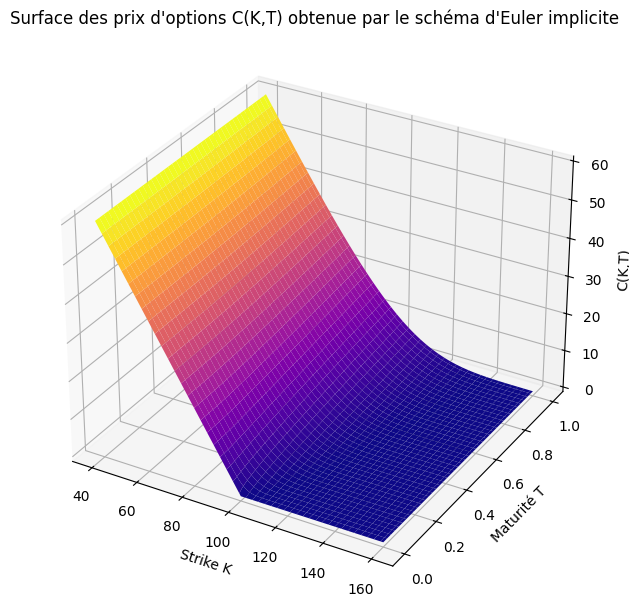

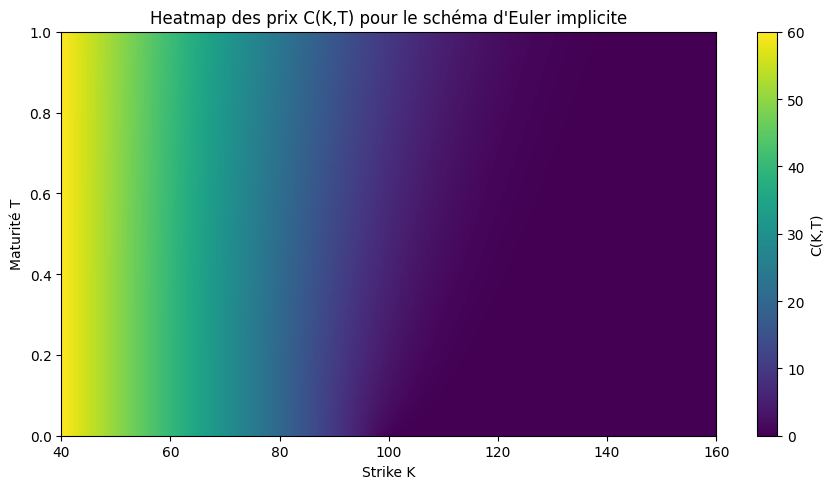

In [105]:
K_mesh, T_mesh = np.meshgrid(K, T)

# --- Surface 3D globale ---
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(K_mesh, T_mesh, C, cmap="plasma", edgecolor="none")
ax.set_xlabel("Strike K")
ax.set_ylabel("Maturité T")
ax.set_zlabel("C(K,T)")
plt.tight_layout()
plt.title("Surface des prix d'options C(K,T) obtenue par le schéma d'Euler implicite")
plt.show()

# --- Heatmap globale ---
plt.figure(figsize=(9, 5))
plt.imshow(C, aspect="auto", origin="lower",
           extent=[K_min, K_max, 0.0, T_max])
plt.colorbar(label="C(K,T)")
plt.xlabel("Strike K")
plt.ylabel("Maturité T")
plt.title("Heatmap des prix C(K,T) pour le schéma d'Euler implicite")
plt.tight_layout()
plt.show()

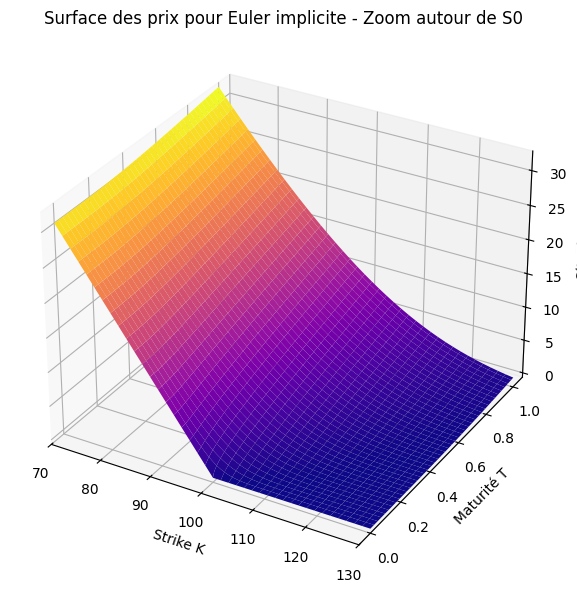

In [106]:
# Zoom autour de S0 pour une meilleure lisibilité
K_plot_min = 0.7 * S0
K_plot_max = 1.3 * S0
mask = (K >= K_plot_min) & (K <= K_plot_max)

K_mesh_plot, T_mesh_plot = np.meshgrid(K[mask], T)
C_plot = C[:, mask]

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(K_mesh_plot, T_mesh_plot, C_plot, cmap="plasma", edgecolor="none")
ax.set_xlabel("Strike K")
ax.set_ylabel("Maturité T")
ax.set_zlabel("C(K,T)")
ax.set_xlim(K_plot_min, K_plot_max)
plt.title("Surface des prix pour Euler implicite - Zoom autour de S0")
plt.tight_layout()
plt.show()

### Coupes 2D : prix en fonction de $K$ et de $T$

Pour interpréter la surface, on trace :

- $K \mapsto C(K,T)$ pour quelques maturités fixées $T$ ;
- $T \mapsto C(K,T)$ pour quelques strikes fixés $K$.

Ces graphes sont souvent plus lisibles qu’une surface 3D et permettent de vérifier
les propriétés qualitatives attendues.

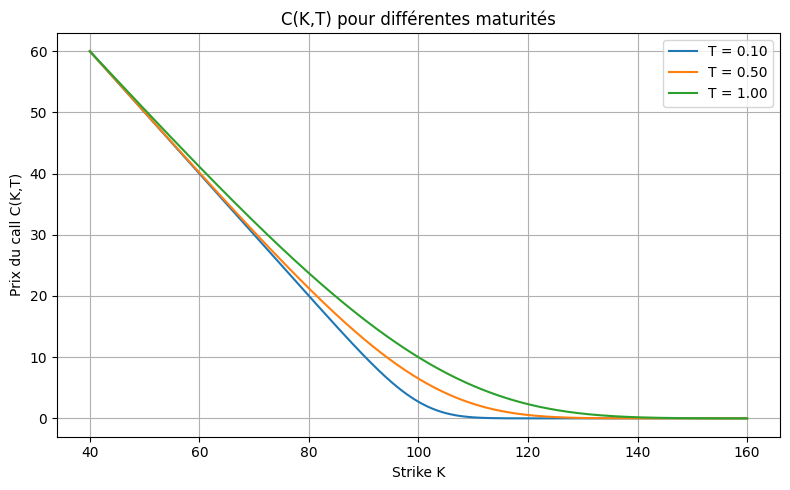

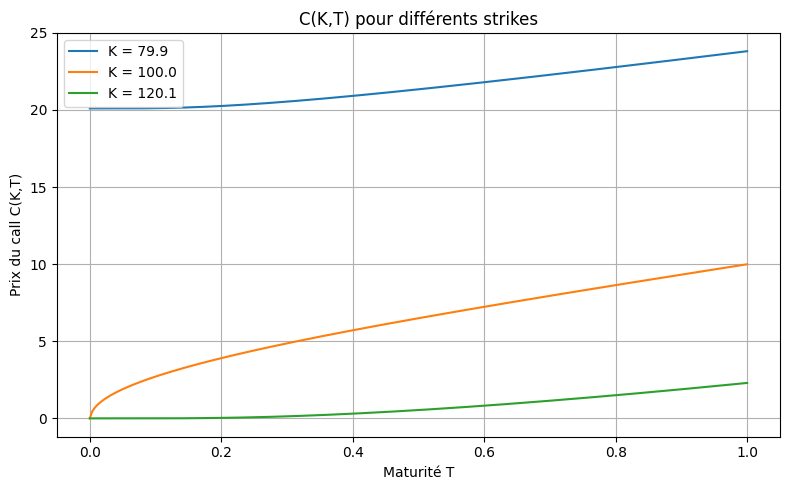

In [107]:
# --- Coupes en K pour quelques maturités ---
plt.figure(figsize=(8, 5))
T_values = [0.1, 0.5, 1.0]
for T_val in T_values:
    idx = np.argmin(np.abs(T - T_val))
    plt.plot(K, C[idx, :], label=f"T = {T[idx]:.2f}")
plt.xlabel("Strike K")
plt.ylabel("Prix du call C(K,T)")
plt.title("C(K,T) pour différentes maturités")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Coupes en T pour quelques strikes ---
plt.figure(figsize=(8, 5))
K_values = [0.8*S0, S0, 1.2*S0]
for K_val in K_values:
    idx = np.argmin(np.abs(K - K_val))
    plt.plot(T, C[:, idx], label=f"K = {K[idx]:.1f}")
plt.xlabel("Maturité T")
plt.ylabel("Prix du call C(K,T)")
plt.title("C(K,T) pour différents strikes")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Tests numériques : monotonie et convexité (conditions d’absence d’arbitrage)

Pour une surface de prix de calls sans arbitrage, on doit avoir :

- Monotonie en strike : $C$ décroît avec $K$ (à $T$ fixé) ;
- Monotonie en maturité : $C$ croît avec $T$ (à $K$ fixé) ;
- Convexité en strike : $C$ est convexe en $K$ (à $T$ fixé).

Numériquement, on vérifie ces propriétés à l’aide de différences finies
sur la grille.

In [108]:
# Monotonie en K : dC/dK <= 0
dC_dK = np.diff(C, axis=1)
print("Monotonie en K OK ?", np.all(dC_dK <= 1e-8))

# Monotonie en T : dC/dT >= 0
dC_dT = np.diff(C, axis=0)
print("Min dérivée en T :", np.min(dC_dT))
print("Monotonie en T OK ?", np.all(dC_dT >= -1e-8))

# Convexité en K : d2C/dK2 >= 0
d2C_dK2 = np.diff(C, n=2, axis=1)
print("Min convexité :", np.min(d2C_dK2))
print("Convexité OK ?", np.all(d2C_dK2 >= -1e-8))

Monotonie en K OK ? True
Min dérivée en T : -7.815970093361102e-14
Monotonie en T OK ? True
Min convexité : -2.842170943040401e-14
Convexité OK ? True


### Visualisation de la volatilité locale

Enfin, on représente $\sigma_{\mathrm{loc}}(K,T)$ sur la grille du solveur afin de vérifier :

- l’ordre de grandeur (pas de valeurs aberrantes),
- la structure qualitative (skew/smile),
- la régularité (absence d’oscillations numériques).

Min sigma_loc (grille PDE) : 0.060230178260774536
Max sigma_loc (grille PDE) : 0.9051061065116957


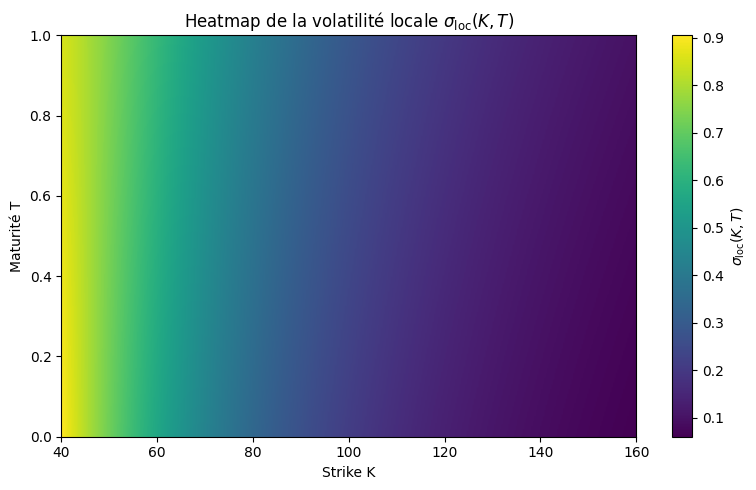

In [109]:
sigma_vals = sigma_loc_KT(K_mesh, T_mesh)

print("Min sigma_loc (grille PDE) :", np.min(sigma_vals))
print("Max sigma_loc (grille PDE) :", np.max(sigma_vals))

# Heatmap
plt.figure(figsize=(8, 5))
plt.imshow(sigma_vals, origin="lower", aspect="auto",
           extent=[K.min(), K.max(), T.min(), T.max()])
plt.colorbar(label=r"$\sigma_{\mathrm{loc}}(K,T)$")
plt.xlabel("Strike K")
plt.ylabel("Maturité T")
plt.title(r"Heatmap de la volatilité locale $\sigma_{\mathrm{loc}}(K,T)$")
plt.tight_layout()
plt.show()

---

## 6.3 Résolution numérique par le schéma de Crank–Nicolson

Le schéma d’Euler implicite, bien qu’inconditionnellement stable pour les
équations paraboliques, demeure d’ordre $1$ en temps. Afin d’améliorer la
précision temporelle tout en conservant une bonne stabilité numérique,
il est naturel d’introduire le schéma de Crank–Nicolson, qui offre une
convergence d’ordre $2$ en temps.

---

### 6.3.1 Construction du schéma de Crank–Nicolson

On conserve les notations introduites précédemment.

Comme dans le cas du schéma implicite, on commence par approcher
la dérivée seconde par rapport au strike par une différence finie centrée
d’ordre deux. Pour $i = 1, \dots, M-1$, on écrit :

$$
\partial_{KK} C(K_i, T_n)
\approx
\frac{C_{i+1}^n - 2 C_i^n + C_{i-1}^n}{(\Delta K)^2}.
$$

On en déduit, pour chaque nœud spatial $K_i$, l’approximation semi-discrète :

$$
\partial_T C_i(T)
=
\frac{1}{2}\sigma_{\mathrm{loc}}^2(K_i,T)\,K_i^2
\frac{C_{i+1}(T) - 2C_i(T) + C_{i-1}(T)}{(\Delta K)^2}.
$$

On obtient ainsi un système d’équations différentielles ordinaires en temps,
que l’on peut écrire sous la forme

$$
\partial_T Q = A_h Q,
$$

où $A_h$ désigne l’opérateur discret associé à la dérivée seconde en strike
pondérée par le coefficient diffusif.

Le schéma de Crank–Nicolson consiste à approximer la dérivée temporelle
par une différence en aval et à évaluer le terme diffusif au point milieu
en temps. On obtient, pour tout $n \in \{0,\dots,N-1\}$ :

$$
\frac{C_i^{n+1} - C_i^n}{\Delta T}
=
\frac{1}{2}
\left(
(A_h C^n)_i + (A_h C^{n+1})_i
\right).
$$

Autrement dit, en développant explicitement le terme diffusif, on a,
pour tout $i \in \{1,\dots,M-1\}$ et tout $n \in \{0,\dots,N-1\}$ :

$$
\frac{C_i^{n+1} - C_i^n}{\Delta T}
=
\frac{1}{4}
\sigma_{\mathrm{loc}}^2(K_i,T_n)\,K_i^2
\frac{C_{i+1}^n - 2C_i^n + C_{i-1}^n}{(\Delta K)^2}
+
\frac{1}{4}
\sigma_{\mathrm{loc}}^2(K_i,T_{n+1})\,K_i^2
\frac{C_{i+1}^{n+1} - 2C_i^{n+1} + C_{i-1}^{n+1}}{(\Delta K)^2}.
$$

Les conditions initiales et aux bords étant indépendantes du schéma
de différences finies utilisé, elles sont identiques à celles du schéma
d’Euler implicite.

---

## 6.3.2 Implémentation en Python

Le schéma de Crank–Nicolson conduit, à chaque pas de temps,
à la résolution d’un système linéaire tridiagonal de la forme :

$$
\left(I - \frac{1}{2}A^{n+1}\right) C^{n+1}
=
\left(I + \frac{1}{2}A^{n}\right) C^{n}.
$$

Comme dans le cas du schéma implicite, la matrice reste tridiagonale.
Nous utilisons donc l’algorithme de Thomas pour la résolution.

Les paramètres numériques retenus sont identiques à ceux du schéma implicite :

$$
S_0 = 100, \quad r = 0, \quad q = 0, \quad
K_{\min} = 0.4S_0, \quad K_{\max} = 1.6S_0,
$$
$$
T_{\max} = 1, \quad M = 400, \quad N = 250.
$$

In [110]:
# ============================================================
# 1) Paramètres globaux
# ============================================================

S0 = 100.0
K_min, K_max = 0.4*S0, 1.6*S0
T_max = 1.0

M = 400   # discrétisation en strike
N = 250   # discrétisation en temps

K = np.linspace(K_min, K_max, M+1)
T = np.linspace(0.0, T_max, N+1)

dK = K[1] - K[0]
dT = T[1] - T[0]

LOGS0 = np.log(S0)

### Définition de la volatilité locale

On réutilise exactement la fonction calibrée précédemment.
La régularité de cette fonction est cruciale pour la stabilité du schéma.

In [111]:
def sigma_loc_KT(K_in, T_in):
    K_in = np.asarray(K_in, dtype=float)
    logK = np.log(K_in)
    x = logK - LOGS0
    return np.exp(
        -1.5496782481424867
        + -2.308300854918231 * x
        + -0.7921730304060329 * x**2
        + 0.3142990744162469 * T_in
        + 0.40720829019854277 * T_in * x
    )

### Conditions initiales et aux bords

Nous imposons :

- condition initiale : $C(K,0) = (S_0-K)^+$,
- bord gauche (Dirichlet cohérent avec la troncature),
- bord droit : $C(K_{\max},T)=0$.

In [112]:
def payoff_call(S0, K_grid):
    return np.maximum(S0 - K_grid, 0.0)

C = np.zeros((N+1, M+1))
C[0,:] = payoff_call(S0, K)

C_left = max(S0 - K_min, 0.0)
C_right = 0.0

def apply_bc(C_slice):
    C_slice[0] = C_left
    C_slice[-1] = C_right

apply_bc(C[0,:])

### Solveur tridiagonal (algorithme de Thomas)

La matrice issue du schéma de Crank–Nicolson est tridiagonale.
On applique l’élimination de Gauss spécialisée (complexité $\mathcal{O}(M)$).

In [113]:
def solve_tridiagonal(a, b, c, d):
    n = b.size
    cp = np.empty(n-1)
    dp = np.empty(n)

    denom = b[0]
    cp[0] = c[0] / denom
    dp[0] = d[0] / denom

    for i in range(1, n-1):
        denom = b[i] - a[i-1]*cp[i-1]
        cp[i] = c[i] / denom
        dp[i] = (d[i] - a[i-1]*dp[i-1]) / denom

    denom = b[n-1] - a[n-2]*cp[n-2]
    dp[n-1] = (d[n-1] - a[n-2]*dp[n-2]) / denom

    x = np.empty(n)
    x[-1] = dp[-1]

    for i in range(n-2, -1, -1):
        x[i] = dp[i] - cp[i]*x[i+1]

    return x

### Boucle temporelle Crank–Nicolson

Le schéma s’écrit :

$$
(I - \tfrac{1}{2}A^{n+1}) C^{n+1}
=
(I + \tfrac{1}{2}A^{n}) C^{n}.
$$

On construit séparément les coefficients aux temps $T_n$ et $T_{n+1}$.

In [114]:
K_inner = K[1:M]

for n in range(N):

    Tn, Tnp1 = T[n], T[n+1]

    sig_n = sigma_loc_KT(K_inner, Tn)
    sig_np1 = sigma_loc_KT(K_inner, Tnp1)

    alpha_n = (dT/(2*dK*dK)) * sig_n**2 * K_inner**2
    alpha_np1 = (dT/(2*dK*dK)) * sig_np1**2 * K_inner**2

    # LHS
    a = -0.5 * alpha_np1[1:]
    b = 1.0 + alpha_np1
    c = -0.5 * alpha_np1[:-1]

    # RHS
    Cn = C[n,:].copy()
    apply_bc(Cn)

    Cn_inner = Cn[1:M]
    Cn_im1 = Cn[0:M-1]
    Cn_ip1 = Cn[2:M+1]

    rhs = (1.0 - alpha_n) * Cn_inner \
            + 0.5 * alpha_n * (Cn_im1 + Cn_ip1)

    rhs[0] += 0.5 * alpha_np1[0] * C_left

    C_next = solve_tridiagonal(a, b, c, rhs)

    C[n+1,1:M] = C_next
    apply_bc(C[n+1,:])

## Représentation de la surface des prix

On représente :

1. Surface 3D sur tout le domaine.
2. Surface 3D restreinte autour de $S_0$.
3. Heatmap 2D.

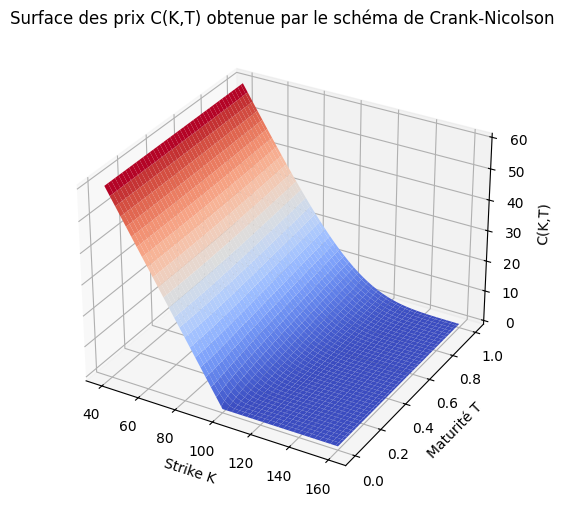

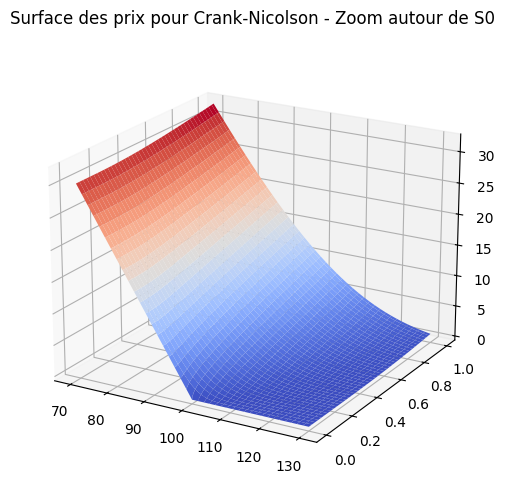

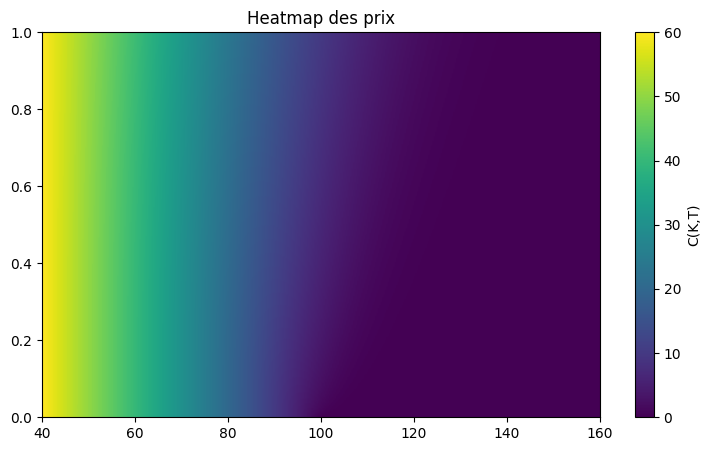

In [115]:
K_mesh, T_mesh = np.meshgrid(K, T)

# Surface 3D globale
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(K_mesh, T_mesh, C, cmap='coolwarm', edgecolor='none')
ax.set_xlabel("Strike K")
ax.set_ylabel("Maturité T")
ax.set_zlabel("C(K,T)")
plt.title("Surface des prix C(K,T) obtenue par le schéma de Crank-Nicolson")
plt.show()

# Zoom visuel
mask = (K >= 0.7*S0) & (K <= 1.3*S0)
K_zoom = K[mask]
K_mesh_z, T_mesh_z = np.meshgrid(K_zoom, T)
C_zoom = C[:,mask]

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(K_mesh_z, T_mesh_z, C_zoom,
                cmap='coolwarm', edgecolor='none')
ax.view_init(elev=20, azim=-60)
plt.title("Surface des prix pour Crank-Nicolson - Zoom autour de S0")
plt.show()

# Heatmap
plt.figure(figsize=(9,5))
plt.imshow(C, origin='lower', aspect='auto',
            extent=[K_min, K_max, 0, T_max])
plt.colorbar(label="C(K,T)")
plt.title("Heatmap des prix")
plt.show()

---

## 6.4 Cas particulier : volatilité constante (Black–Scholes)

Dans cette partie, nous considérons le cas où la volatilité locale est constante :

$$
\sigma_{\mathrm{loc}}(K,T) = \sigma_0 > 0,
\qquad
\forall (K,T) \in [K_{\min}, K_{\max}] \times ]0,T_{\max}].
$$

L’équation de Dupire (dans le cadre forward avec $r=q=0$) se réduit alors à :

$$
\partial_T C(K,T)
=
\frac{1}{2}\sigma_0^2\,K^2\,\partial_{KK}C(K,T).
\tag{14}
$$

Ce cas correspond au modèle de Black–Scholes exprimé en variable strike et
constitue un cas de référence pour l’étude des situations où la volatilité locale
dépend explicitement de $K$ et de $T$.

Afin de définir un cas de référence à volatilité constante cohérent avec le modèle
de volatilité locale calibré précédemment, nous fixons

$$
\sigma_0 := \sigma_{\mathrm{loc}}(S_0, T_{\max}/2).
$$

L’idée est de choisir un point représentatif du domaine numérique,
à savoir un strike central ($K \approx S_0$) et une maturité intermédiaire,
afin d’obtenir une valeur de volatilité moyenne qui ne privilégie ni le régime
court terme ni le régime long terme.

Les différences observées le long de la surface $C(K,T)$ entre le cas
constant et le cas général proviennent alors uniquement de la dépendance
en $(K,T)$ de $\sigma_{\mathrm{loc}}$.


In [116]:
# Calcul de sigma0 = sigma_loc(S0, T_max/2)

T_mid = 0.5 * T_max
sigma0 = float(sigma_loc_KT(S0, T_mid))

print(f"sigma0 = sigma_loc(S0, T_max/2) = {sigma0:.6f}  (~ {100*sigma0:.2f}%)")

sigma0 = sigma_loc(S0, T_max/2) = 0.248446  (~ 24.84%)



On obtient ainsi numériquement
$$
\sigma_0 \approx 24.8\%.
$$

Le schéma retenu est Crank–Nicolson, d’ordre 2 en temps, et la résolution
à chaque pas de temps se ramène à un système tridiagonal résolu par l’algorithme de Thomas.

On représentera ensuite la surface $C(K,T)$ en 3D (domaine complet et zoom)
ainsi que des heatmaps.

In [117]:
# ============================================================
# Paramètres (identiques aux autres sections)
# ============================================================
S0 = 100.0
K_min, K_max = 0.4*S0, 1.6*S0
T_max = 1.0

M = 400   # nombre d'intervalles en strike (=> M+1 points)
N = 250   # nombre d'intervalles en temps  (=> N+1 points)

# Grilles
K = np.linspace(K_min, K_max, M+1)
T = np.linspace(0.0, T_max, N+1)

dK = K[1] - K[0]
dT = T[1] - T[0]

In [118]:
def sigma_loc_const(K_in, T_in):
    """
    Volatilité 'locale' constante σ0.
    On conserve une signature compatible avec les fonctions précédentes :
    renvoie un tableau broadcastable de même forme que (K_in, T_in).
    """
    K_in = np.asarray(K_in, dtype=float)
    T_in = np.asarray(T_in, dtype=float)
    return sigma0 * np.ones(np.broadcast(K_in, T_in).shape, dtype=float)

print(f"sigma0 = {sigma0:.6f}  (~ {100*sigma0:.2f}%)")

sigma0 = 0.248446  (~ 24.84%)


### Conditions initiales et aux bords

- Condition initiale (payoff call) :

$$
C(K,0) = (S_0-K)^+.
$$

- Conditions aux bords sur le domaine tronqué :

$$
C(K_{\min},T)=S_0-K_{\min}, \qquad C(K_{\max},T)=0.
$$

Ces conditions de Dirichlet sont imposées à chaque itération temporelle.

In [119]:
def payoff_call(S0, K_grid):
    return np.maximum(S0 - K_grid, 0.0)

# Matrice C[n,i] ≈ C(K_i, T_n)
C = np.zeros((N+1, M+1), dtype=float)

# Condition initiale
C[0, :] = payoff_call(S0, K)

# Conditions aux bords (Dirichlet)
C_left = max(S0 - K_min, 0.0)
C_right = 0.0

def apply_bc(C_slice):
    """Impose les conditions aux bords sur une tranche C_slice = C[n,:]."""
    C_slice[0] = C_left
    C_slice[-1] = C_right

apply_bc(C[0, :])

### Résolution tridiagonale : algorithme de Thomas

Le schéma de Crank–Nicolson conduit à un système linéaire tridiagonal
de taille $(M-1)$ à chaque pas de temps. La structure tridiagonale permet
une résolution en temps linéaire $\mathcal{O}(M)$ via l’algorithme de Thomas
(élimination avant + substitution arrière).

In [120]:
def solve_tridiagonal(a, b, c, d):
    """
    Résout Ax=d pour A tridiagonale.
    a : sous-diagonale (taille m-1)
    b : diagonale      (taille m)
    c : sur-diagonale  (taille m-1)
    d : second membre  (taille m)
    """
    m = b.size
    cp = np.empty(m-1, dtype=float)
    dp = np.empty(m, dtype=float)

    denom = b[0]
    if abs(denom) < 1e-15:
        raise ValueError("Pivot quasi nul (b[0]).")

    cp[0] = c[0] / denom
    dp[0] = d[0] / denom

    for i in range(1, m-1):
        denom = b[i] - a[i-1]*cp[i-1]
        if abs(denom) < 1e-15:
            raise ValueError(f"Pivot quasi nul (i={i}).")
        cp[i] = c[i] / denom
        dp[i] = (d[i] - a[i-1]*dp[i-1]) / denom

    denom = b[m-1] - a[m-2]*cp[m-2]
    if abs(denom) < 1e-15:
        raise ValueError("Pivot quasi nul (dernier).")
    dp[m-1] = (d[m-1] - a[m-2]*dp[m-2]) / denom

    x = np.empty(m, dtype=float)
    x[m-1] = dp[m-1]
    for i in range(m-2, -1, -1):
        x[i] = dp[i] - cp[i]*x[i+1]

    return x

### Boucle Crank–Nicolson (volatilité constante)

Pour chaque $n$, le schéma de Crank–Nicolson s’écrit :

$$
\left(I - \frac12 A\right)C^{n+1} = \left(I + \frac12 A\right)C^n,
$$

où l’opérateur $A$ discrétise le terme diffusif
$\frac12\sigma_0^2 K^2\partial_{KK}$.

Même si $\sigma_0$ est constant, le coefficient effectif dépend de $K$
via le facteur $K^2$.

On introduit
$$
\alpha_i = \frac{\Delta T}{2(\Delta K)^2}\sigma_0^2 K_i^2,
$$
puis on assemble :

- le membre de gauche (tridiagonal),
- le membre de droite,
- les contributions des bords.

In [121]:
# Indices intérieurs : i=1,...,M-1
K_inner = K[1:M]

for n in range(N):
    # Ici sigma est constant : on garde la structure générale
    sig_n = sigma_loc_const(K_inner, T[n])
    sig_np1 = sigma_loc_const(K_inner, T[n+1])

    alpha_n = (dT/(2*dK*dK)) * (sig_n**2)   * (K_inner**2)
    alpha_np1 = (dT/(2*dK*dK)) * (sig_np1**2) * (K_inner**2)

    # ----- Membre gauche : (I - 1/2 A^{n+1}) -----
    # diag : 1 + alpha_np1 ; sous/sur diag : -0.5 alpha_np1
    a = -0.5 * alpha_np1[1:]      # sous-diagonale (M-2)
    b = 1.0 + alpha_np1           # diagonale      (M-1)
    c = -0.5 * alpha_np1[:-1]     # sur-diagonale  (M-2)

    # ----- Membre droit : (I + 1/2 A^n) C^n -----
    Cn = C[n, :].copy()
    apply_bc(Cn)

    Cn_inner = Cn[1:M]
    Cn_im1 = Cn[0:M-1]   # inclut bord gauche
    Cn_ip1 = Cn[2:M+1]   # inclut bord droit

    rhs = (1.0 - alpha_n) * Cn_inner + 0.5 * alpha_n * (Cn_im1 + Cn_ip1)

    # Contribution du bord gauche au temps n+1 côté LHS
    rhs[0] += 0.5 * alpha_np1[0] * C_left
    # Bord droit = 0, mais on laisse la ligne pour clarté
    rhs[-1] += 0.5 * alpha_np1[-1] * C_right

    # Résolution tridiagonale
    C_next_inner = solve_tridiagonal(a, b, c, rhs)

    # Mise à jour
    C[n+1, 1:M] = C_next_inner
    apply_bc(C[n+1, :])

### Visualisations : surface 3D, zoom et heatmaps

On représente ensuite :

1. $C(K,T)$ en surface 3D sur le domaine complet $[K_{\min},K_{\max}]$ ;
2. un zoom autour de $S_0$ (zone la plus informative) ;
3. une heatmap 2D (lecture immédiate de la structure en $(K,T)$).

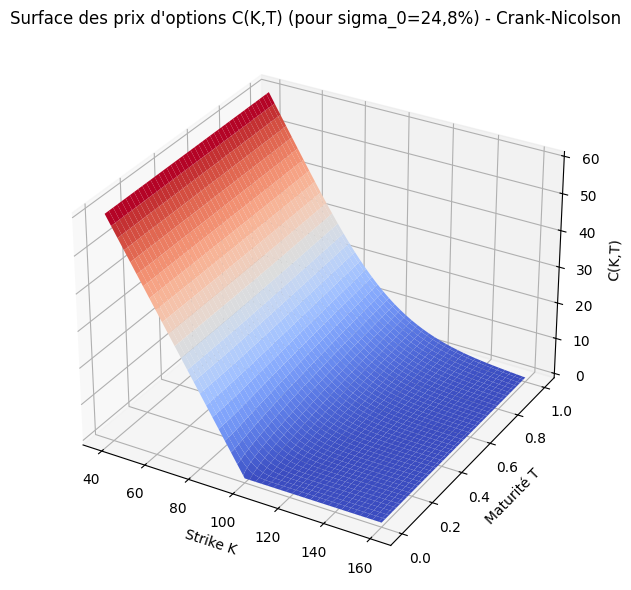

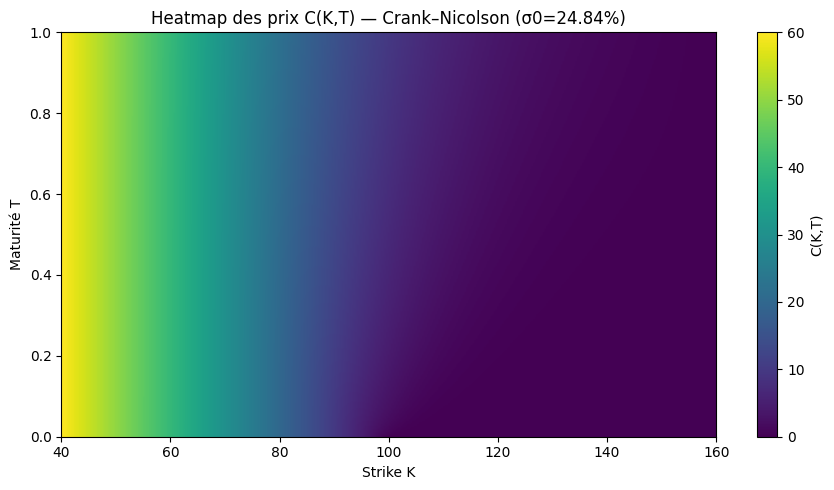

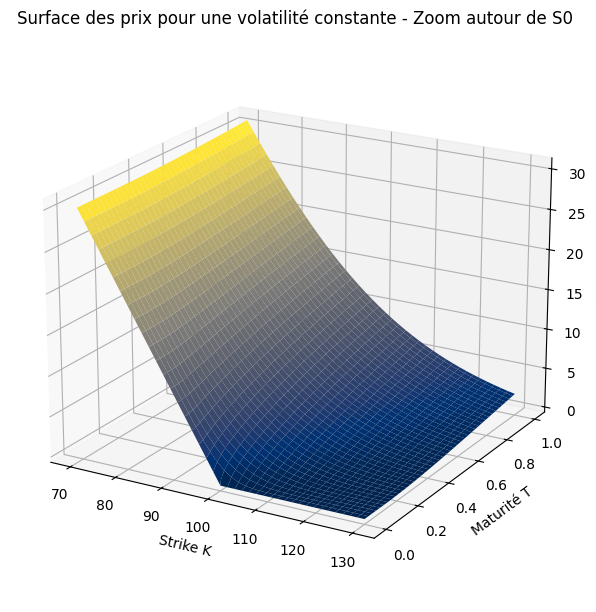

In [122]:
K_mesh, T_mesh = np.meshgrid(K, T)

# --- Surface 3D complète ---
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(K_mesh, T_mesh, C, cmap="coolwarm", edgecolor="none", antialiased=True)
ax.set_xlabel("Strike K")
ax.set_ylabel("Maturité T")
ax.set_zlabel("C(K,T)")
plt.title("Surface des prix d'options C(K,T) (pour sigma_0=24,8%) - Crank-Nicolson")
plt.tight_layout()
plt.show()

# --- Heatmap complète ---
plt.figure(figsize=(9, 5))
plt.imshow(C, aspect="auto", origin="lower", extent=[K_min, K_max, 0.0, T_max])
plt.colorbar(label="C(K,T)")
plt.xlabel("Strike K")
plt.ylabel("Maturité T")
plt.title(f"Heatmap des prix C(K,T) — Crank–Nicolson (σ0={sigma0:.2%})")
plt.tight_layout()
plt.show()

# --- Zoom autour de S0 ---
K_plot_min, K_plot_max = 0.7*S0, 1.3*S0
mask = (K >= K_plot_min) & (K <= K_plot_max)

K_mesh_zoom, T_mesh_zoom = np.meshgrid(K[mask], T)
C_zoom = C[:, mask]

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(K_mesh_zoom, T_mesh_zoom, C_zoom, cmap="cividis", edgecolor="none", antialiased=True)
ax.set_xlabel("Strike K")
ax.set_ylabel("Maturité T")
ax.set_zlabel("C(K,T)")
ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.title("Surface des prix pour une volatilité constante - Zoom autour de S0")
plt.show()

---

# 7 Analyse et interprétation des résultats

## 7.1 Comparaison des schémas d’Euler implicite et de Crank–Nicolson

Afin de comparer les deux schémas, on commence par quantifier l’écart entre
les surfaces de prix obtenues.

Plus précisément, à maillage identique $(K_i,T_n)$, on considère la différence
point par point :

$$
\Delta C(K_i,T_n)
=
C_{\mathrm{CN}}(K_i,T_n)
-
C_{\mathrm{imp}}(K_i,T_n).
$$

On souhaite visualiser la quantité $|\Delta C(K_i,T_n)|$
sur tout le domaine discrétisé.

L’analyse porte donc sur :

- l’erreur maximale,
- l’erreur moyenne,
- la norme quadratique moyenne,
- ainsi que des représentations graphiques (heatmap et surfaces 3D).

## Réexécution des solveurs dans le notebook

Afin de rendre le notebook totalement autonome, nous redéfinissons ici
les fonctions `solve_implicite()` et `solve_CN()`.

Le code est strictement identique à celui présenté dans les sections précédentes.
Il est simplement réintégré ici pour permettre la comparaison directe
des deux schémas sans dépendance externe.

In [123]:
def solve_implicite():
    """
    Résolution de l'EDP de Dupire par schéma d'Euler implicite.
    Code identique à la section 6.2.
    """

    S0 = 100.0
    K_min, K_max = 0.4*S0, 1.6*S0
    T_max = 1.0
    M, N = 400, 250

    K = np.linspace(K_min, K_max, M+1)
    T = np.linspace(0.0, T_max, N+1)
    dK = K[1] - K[0]
    dT = T[1] - T[0]

    LOGS0 = np.log(S0)

    def sigma_loc(K_in, T_in):
        K_in = np.asarray(K_in, dtype=float)
        logK = np.log(K_in)
        x = logK - LOGS0
        return np.exp(
            -1.5496782481424867
            + -2.308300854918231 * x
            + -0.7921730304060329 * x**2
            + 0.3142990744162469 * T_in
            + 0.40720829019854277 * T_in * x
        )

    def payoff_call(S0, K_grid):
        return np.maximum(S0 - K_grid, 0.0)

    C = np.zeros((N+1, M+1))
    C[0,:] = payoff_call(S0, K)

    C_left = max(S0 - K_min, 0.0)
    C_right = 0.0

    def apply_bc(C_slice):
        C_slice[0] = C_left
        C_slice[-1] = C_right

    apply_bc(C[0,:])

    def solve_tridiagonal(a, b, c, d):
        n = b.size
        cp = np.empty(n-1)
        dp = np.empty(n)
        cp[0] = c[0] / b[0]
        dp[0] = d[0] / b[0]
        for i in range(1, n-1):
            denom = b[i] - a[i-1]*cp[i-1]
            cp[i] = c[i] / denom
            dp[i] = (d[i] - a[i-1]*dp[i-1]) / denom
        dp[-1] = (d[-1] - a[-1]*dp[-2]) / (b[-1] - a[-1]*cp[-2])
        x = np.empty(n)
        x[-1] = dp[-1]
        for i in range(n-2, -1, -1):
            x[i] = dp[i] - cp[i]*x[i+1]
        return x

    K_inner = K[1:M]

    for n in range(N):
        sig = sigma_loc(K_inner, T[n+1])
        alpha = (dT/(2*dK*dK)) * sig**2 * K_inner**2

        a = -alpha[1:]
        b = 1 + 2*alpha
        c = -alpha[:-1]

        rhs = C[n,1:M].copy()
        rhs[0] -= (-alpha[0]) * C_left

        C_next = solve_tridiagonal(a, b, c, rhs)
        C[n+1,1:M] = C_next
        apply_bc(C[n+1,:])

    return C, K, T

def solve_CN():
    """
    Résolution de l'EDP de Dupire par schéma de Crank–Nicolson.
    Code identique à la section 6.3.
    """

    import numpy as np

    S0 = 100.0
    K_min, K_max = 0.4*S0, 1.6*S0
    T_max = 1.0
    M, N = 400, 250

    K = np.linspace(K_min, K_max, M+1)
    T = np.linspace(0.0, T_max, N+1)
    dK = K[1] - K[0]
    dT = T[1] - T[0]

    LOGS0 = np.log(S0)

    def sigma_loc(K_in, T_in):
        K_in = np.asarray(K_in, dtype=float)
        logK = np.log(K_in)
        x = logK - LOGS0
        return np.exp(
            -1.5496782481424867
            + -2.308300854918231 * x
            + -0.7921730304060329 * x**2
            + 0.3142990744162469 * T_in
            + 0.40720829019854277 * T_in * x
        )

    def payoff_call(S0, K_grid):
        return np.maximum(S0 - K_grid, 0.0)

    C = np.zeros((N+1, M+1))
    C[0,:] = payoff_call(S0, K)

    C_left = max(S0 - K_min, 0.0)
    C_right = 0.0

    def apply_bc(C_slice):
        C_slice[0] = C_left
        C_slice[-1] = C_right

    apply_bc(C[0,:])

    def solve_tridiagonal(a, b, c, d):
        n = b.size
        cp = np.empty(n-1)
        dp = np.empty(n)
        cp[0] = c[0] / b[0]
        dp[0] = d[0] / b[0]
        for i in range(1, n-1):
            denom = b[i] - a[i-1]*cp[i-1]
            cp[i] = c[i] / denom
            dp[i] = (d[i] - a[i-1]*dp[i-1]) / denom
        dp[-1] = (d[-1] - a[-1]*dp[-2]) / (b[-1] - a[-1]*cp[-2])
        x = np.empty(n)
        x[-1] = dp[-1]
        for i in range(n-2, -1, -1):
            x[i] = dp[i] - cp[i]*x[i+1]
        return x

    K_inner = K[1:M]

    for n in range(N):
        sig_n = sigma_loc(K_inner, T[n])
        sig_np1 = sigma_loc(K_inner, T[n+1])

        alpha_n = (dT/(2*dK*dK)) * sig_n**2 * K_inner**2
        alpha_np1 = (dT/(2*dK*dK)) * sig_np1**2 * K_inner**2

        a = -0.5 * alpha_np1[1:]
        b = 1 + alpha_np1
        c = -0.5 * alpha_np1[:-1]

        Cn = C[n,:].copy()
        apply_bc(Cn)

        Cn_inner = Cn[1:M]
        Cn_im1 = Cn[0:M-1]
        Cn_ip1 = Cn[2:M+1]

        rhs = (1 - alpha_n) * Cn_inner + 0.5 * alpha_n * (Cn_im1 + Cn_ip1)
        rhs[0] += 0.5 * alpha_np1[0] * C_left

        C_next = solve_tridiagonal(a, b, c, rhs)
        C[n+1,1:M] = C_next
        apply_bc(C[n+1,:])

    return C, K, T

In [124]:
# Résolution des deux schémas
C_CN, K_CN, T_CN = solve_CN()
C_imp, K_imp, T_imp = solve_implicite()

# Vérification que les grilles sont identiques
assert np.allclose(K_CN, K_imp), "Grilles K différentes."
assert np.allclose(T_CN, T_imp), "Grilles T différentes."

# Grilles pour affichage
K_mesh, T_mesh = np.meshgrid(K_CN, T_CN)

Les deux schémas étant résolus sur la même grille $(K_i,T_n)$,
la comparaison point par point est directement possible.

On calcule la différence absolue :

$$
|\Delta C| = |C_{\mathrm{CN}} - C_{\mathrm{imp}}|.
$$

In [125]:
# =====================================================
# 2) Calcul des écarts
# =====================================================

diff_price = np.abs(C_CN - C_imp)

print("==== Écart prix CN vs implicite ====")
print("Erreur max      :", np.max(diff_price))
print("Erreur moyenne  :", np.mean(diff_price))
print("Norme L2 (RMS)  :", np.sqrt(np.mean(diff_price**2)))

==== Écart prix CN vs implicite ====
Erreur max      : 0.1857448141744948
Erreur moyenne  : 0.0018636249179733223
Norme L2 (RMS)  : 0.0028446074801412704


Ces indicateurs quantifient la proximité globale des deux solutions numériques.

On procède ensuite à des visualisations sur l’ensemble du domaine.

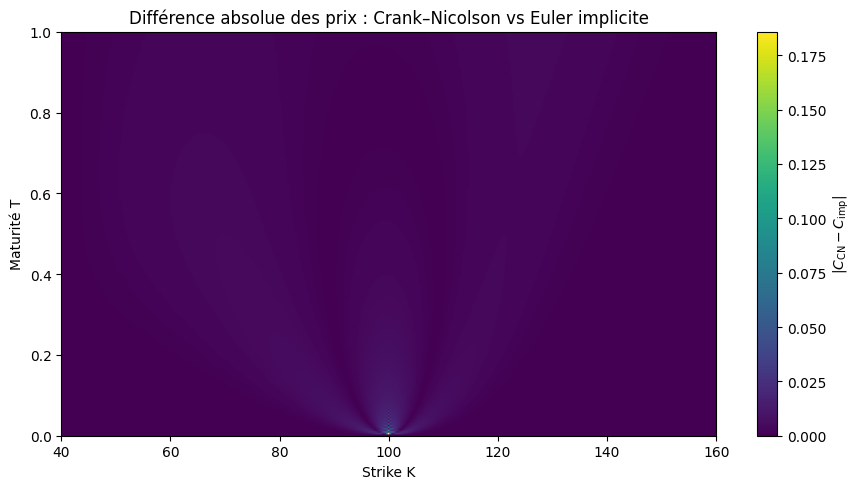

In [126]:
# =====================================================
# 3) Heatmap globale
# =====================================================

plt.figure(figsize=(9, 5))
plt.imshow(
    diff_price,
    aspect="auto",
    origin="lower",
    extent=[K_CN.min(), K_CN.max(), T_CN.min(), T_CN.max()],
)
plt.colorbar(label=r"$|C_{\mathrm{CN}} - C_{\mathrm{imp}}|$")
plt.xlabel("Strike K")
plt.ylabel("Maturité T")
plt.title("Différence absolue des prix : Crank–Nicolson vs Euler implicite")
plt.tight_layout()
plt.show()

La heatmap permet d’identifier les zones où l’écart est maximal.
En général, les différences sont plus marquées :

- aux maturités longues,
- dans les zones de strike extrêmes,
- lorsque le maillage est relativement grossier.

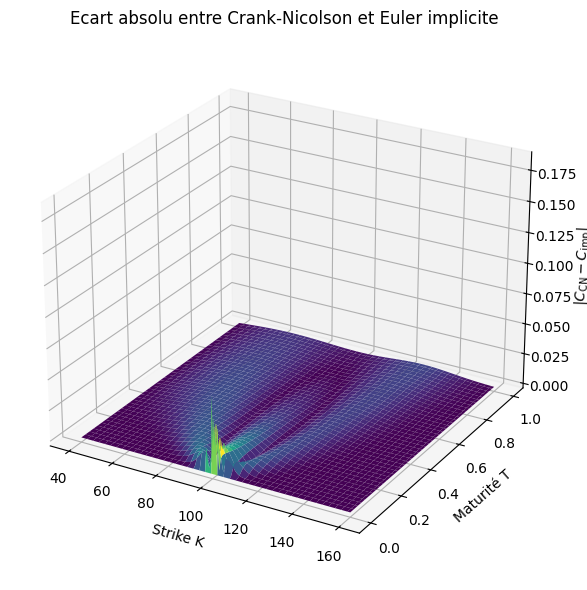

In [127]:
# =====================================================
# 4) Surface 3D complète
# =====================================================

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    K_mesh, T_mesh, diff_price,
    cmap="viridis",
    edgecolor="none",
    antialiased=True
)

ax.set_xlabel("Strike K")
ax.set_ylabel("Maturité T")
ax.set_zlabel(r"$|C_{\mathrm{CN}} - C_{\mathrm{imp}}|$")
ax.view_init(elev=25, azim=-60)
plt.title("Ecart absolu entre Crank-Nicolson et Euler implicite")
plt.tight_layout()
plt.show()

La représentation 3D permet d’apprécier la structure spatiale de l’erreur.

Cependant, lorsque l’erreur maximale est localisée,
la visualisation peut être dominée par un pic isolé.
Il est donc utile d’introduire un zoom vertical.

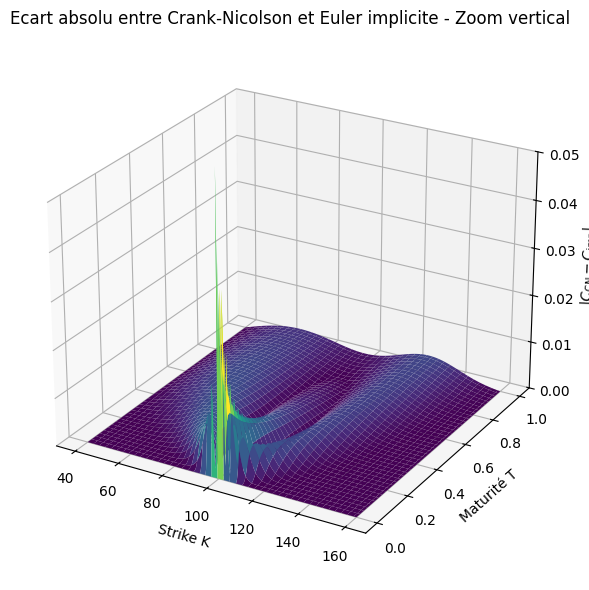

In [128]:
# =====================================================
# 5) Surface 3D avec zoom vertical
# =====================================================

zmax_price = 0.05  # seuil d'affichage vertical

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    K_mesh, T_mesh, diff_price,
    cmap="viridis",
    edgecolor="none",
    antialiased=True
)

ax.set_zlim(0, zmax_price)
ax.set_xlabel("Strike K")
ax.set_ylabel("Maturité T")
ax.set_zlabel(r"$|C_{\mathrm{CN}} - C_{\mathrm{imp}}|$")
ax.view_init(elev=25, azim=-60)
plt.title("Ecart absolu entre Crank-Nicolson et Euler implicite - Zoom vertical")
plt.tight_layout()
plt.show()

Ce zoom permet de mieux visualiser les écarts faibles,
qui sont autrement invisibles face aux valeurs maximales.

On observe un pic localisé aux petites maturités, centré autour du strike at-the-money $K \approx S_0$, qui reflète la faible régularité de la condition initiale. En effet, la fonction payoff $(S_0 - K)^+$ est continue mais sa dérivée seconde est singulière au point $K = S_0$, ce qui se traduit par une concentration initiale de la courbure. Le schéma de Crank–Nicolson, en moyennant l’opérateur diffusif entre $T_n$ et $T_{n+1}$, capture plus fidèlement cette concentration, tandis que le schéma d’Euler implicite introduit un amortissement numérique plus marqué. Lorsque la maturité augmente, le caractère diffusif de l’équation régularise progressivement la solution, ce qui explique la diminution rapide de l’écart entre les deux schémas pour $T$ plus grand.

---

## 7.2 Validation de la calibration de la volatilité locale

L’objectif de cette section est de vérifier que la chaîne de construction suivante
est cohérente :

$$
\sigma_{\mathrm{imp}}^{\mathrm{cible}}
\;\longrightarrow\;
\sigma_{\mathrm{loc}}
\;\longrightarrow\;
C_{\mathrm{PDE}}
\;\longrightarrow\;
\sigma_{\mathrm{imp}}^{\mathrm{PDE}}.
$$

Autrement dit :

1. On part d’une surface implicite cible.
2. On en déduit une volatilité locale par la formule de Dupire.
3. On résout numériquement l’EDP.
4. On reconstruit la volatilité implicite à partir des prix numériques obtenus.
5. On compare cette surface reconstruite à la surface cible initiale.

Si le modèle et la discrétisation sont cohérents, l’écart doit rester faible
dans le domaine de calibration.

### Étape 1 — Surface implicite cible

Nous rappelons la forme choisie pour la surface implicite cible :

$$
\sigma_{\mathrm{imp}}^{\mathrm{cible}}(K,T)
=
\sigma_0 + \alpha \log\left(\frac{K}{S_0}\right) + \beta T.
$$

Cette surface est purement analytique : elle sert de référence.

In [129]:
# Paramètres de la surface implicite cible
S0 = 100.0
sigma0 = 0.20
alpha  = -0.25
beta   = 0.05

def sigma_imp_target(K, T):
    """
    Surface implicite cible analytique.
    
    Paramètres
    ----------
    K : strike
    T : maturité
    
    Retour
    ------
    sigma_imp(K,T)
    """
    return sigma0 + alpha * np.log(K / S0) + beta * T

Remarque importante : cette surface est celle qui a servi à générer les prix
dans la calibration précédente. Si tout est cohérent, la surface reconstruite
devrait la reproduire dans la zone centrale du domaine.

### Étape 2 — Reconstruction de la volatilité implicite

On dispose maintenant des prix numériques $C_{\mathrm{PDE}}(K,T)$ issus
de la résolution de l’EDP.

Pour chaque couple $(K,T)$, on cherche la volatilité implicite
$\sigma_{\mathrm{imp}}^{\mathrm{PDE}}(K,T)$ telle que :

$$
C_{\mathrm{BS}}(S_0,K,T,\sigma)
=
C_{\mathrm{PDE}}(K,T).
$$

Il s’agit d’une équation scalaire en $\sigma$, que l’on résout par la méthode de Newton.

In [ ]:
def bs_call_price(S0, K, T, sigma):
    """
    Prix Black–Scholes (r=q=0).
    """
    if T <= 0 or sigma <= 0:
        return max(S0 - K, 0.0)

    d1 = (np.log(S0 / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    return S0 * norm.cdf(d1) - K * norm.cdf(d2)


def bs_vega(S0, K, T, sigma):
    """
    Dérivée du prix par rapport à sigma.
    Nécessaire pour la méthode de Newton.
    """
    if T <= 0:
        return 0.0
    d1 = (np.log(S0 / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return S0 * np.sqrt(T) * norm.pdf(d1)


def implied_volatility(S0, K, T, price, tol=1e-8, max_iter=100):
    """
    Résolution de C_BS = price par méthode de Newton.
    
    On part d'une initialisation sigma = 0.2,
    puis on itère :
        sigma <- sigma - f(sigma)/f'(sigma)
    """
    sigma = 0.2  # initialisation raisonnable

    for _ in range(max_iter):

        f = bs_call_price(S0, K, T, sigma) - price

        if abs(f) < tol:
            return sigma

        vega = bs_vega(S0, K, T, sigma)

        if vega < 1e-12:
            break

        sigma = sigma - f / vega

        # garde-fous numériques
        sigma = max(sigma, 1e-8)
        sigma = min(sigma, 5.0)

    return sigma

On applique maintenant cette reconstruction sur toute la grille $(K_i,T_n)$. **Il est normal que l'exécution soit longue.**

In [131]:
# Reconstruction complète sur la grille
sigma_imp_PDE = np.full_like(C_CN, np.nan)

for n in range(len(T_CN)):
    for i in range(len(K_CN)):
        if T_CN[n] > 0:
            sigma_imp_PDE[n, i] = implied_volatility(
                S0,
                K_CN[i],
                T_CN[n],
                C_CN[n, i]
            )

On définit l’écart point par point :

$$
\Delta \sigma_{\mathrm{imp}}(K,T)
=
\left|
\sigma_{\mathrm{imp}}^{\mathrm{PDE}}(K,T)
-
\sigma_{\mathrm{imp}}^{\mathrm{cible}}(K,T)
\right|.
$$

Ce champ scalaire permet de quantifier la qualité de la reproduction.

In [132]:
# Grille mesh pour affichage
K_mesh, T_mesh = np.meshgrid(K_CN, T_CN)

# Surface cible
sigma_imp_cible = sigma_imp_target(K_mesh, T_mesh)

# Écart absolu
diff_sigma = np.abs(sigma_imp_PDE - sigma_imp_cible)

print("=== Domaine complet ===")
print("max |Δσ|  :", np.nanmax(diff_sigma))
print("mean|Δσ| :", np.nanmean(diff_sigma))

=== Domaine complet ===
max |Δσ|  : 0.4772046692588635
mean|Δσ| : 0.07553418463417058


### Visualisation sur le domaine complet

On représente l’écart sur tout le domaine discretisé.

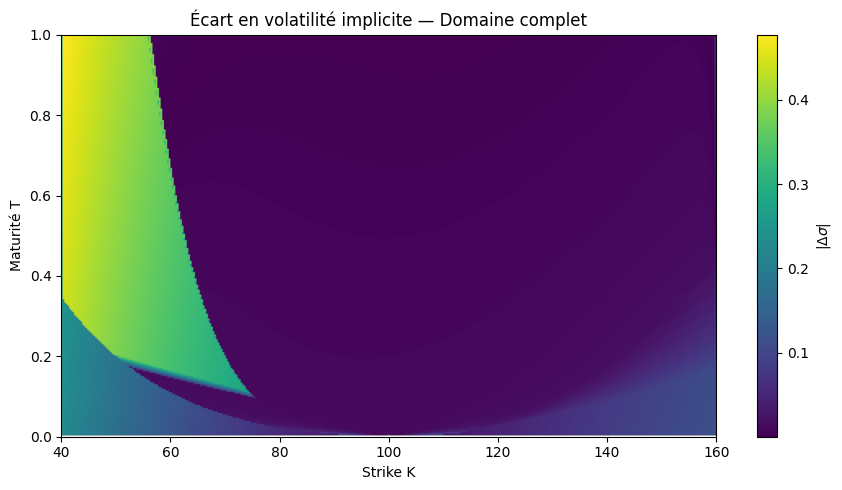

In [133]:
plt.figure(figsize=(9,5))
plt.imshow(
    diff_sigma,
    aspect="auto",
    origin="lower",
    extent=[K_CN.min(), K_CN.max(), T_CN.min(), T_CN.max()]
)
plt.colorbar(label=r"$|\Delta \sigma|$")
plt.xlabel("Strike K")
plt.ylabel("Maturité T")
plt.title("Écart en volatilité implicite — Domaine complet")
plt.tight_layout()
plt.show()

On observe généralement des écarts plus importants :

- aux strikes très faibles,
- aux maturités très petites.

Ces zones correspondent à des régions éloignées du domaine de calibration
et fortement influencées par la singularité initiale.

Afin d’obtenir une comparaison pertinente,
on restreint l’analyse à une zone autour de l’at-the-money :

$$
K \in [0.8S_0,1.2S_0],
\qquad
T \ge 0.05.
$$

In [134]:
K_low, K_high = 0.8*S0, 1.2*S0
T_low = 0.05

maskK = (K_CN >= K_low) & (K_CN <= K_high)
maskT = (T_CN >= T_low)

diff_sigma_sub = diff_sigma[np.ix_(maskT, maskK)]

print("=== Domaine restreint ===")
print("max |Δσ|  :", np.nanmax(diff_sigma_sub))
print("mean|Δσ| :", np.nanmean(diff_sigma_sub))

=== Domaine restreint ===
max |Δσ|  : 0.01719744133091386
mean|Δσ| : 0.005934934416569705


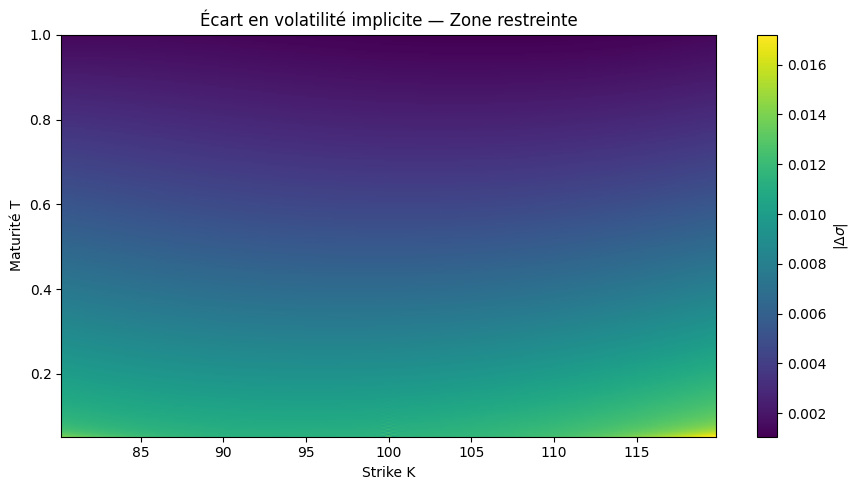

In [135]:
plt.figure(figsize=(9,5))
plt.imshow(
    diff_sigma_sub,
    aspect="auto",
    origin="lower",
    extent=[K_CN[maskK].min(), K_CN[maskK].max(),
            T_CN[maskT].min(), T_CN[maskT].max()]
)
plt.colorbar(label=r"$|\Delta \sigma|$")
plt.xlabel("Strike K")
plt.ylabel("Maturité T")
plt.title("Écart en volatilité implicite — Zone restreinte")
plt.tight_layout()
plt.show()

Dans cette zone restreinte, l’écart reste faible et décroît lorsque la maturité augmente.

Ce comportement est cohérent avec le caractère régularisant de l’opérateur
parabolique de Dupire : à mesure que $T$ croît, la diffusion en strike
lisse la solution et atténue les erreurs locales de discrétisation.

La validation numérique confirme ainsi la cohérence globale de la calibration.

### Représentation 3D de l’écart sur le domaine complet

La représentation tridimensionnelle permet de visualiser
la structure géométrique de l’erreur sur le domaine $(K,T)$.
Elle met en évidence les pics localisés aux petites maturités.

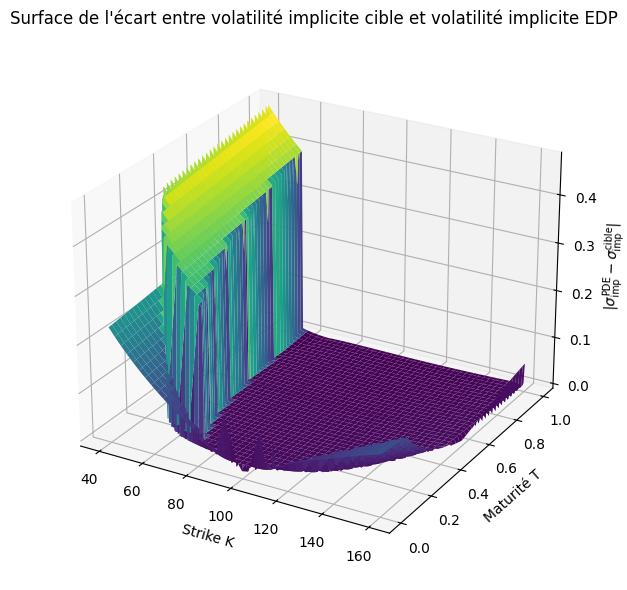

In [136]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    K_mesh,
    T_mesh,
    diff_sigma,
    cmap="viridis",
    edgecolor="none",
    antialiased=True
)

ax.set_xlabel("Strike K")
ax.set_ylabel("Maturité T")
ax.set_zlabel(r"$|\sigma_{\mathrm{imp}}^{\mathrm{PDE}}-\sigma_{\mathrm{imp}}^{\mathrm{cible}}|$")
ax.view_init(elev=25, azim=-60)
plt.title("Surface de l'écart entre volatilité implicite cible et volatilité implicite EDP")
plt.tight_layout()
plt.show()

### Représentation 3D sur la zone restreinte

On restreint à $K \in [0.8S_0,1.2S_0]$ et $T \ge 0.05$.

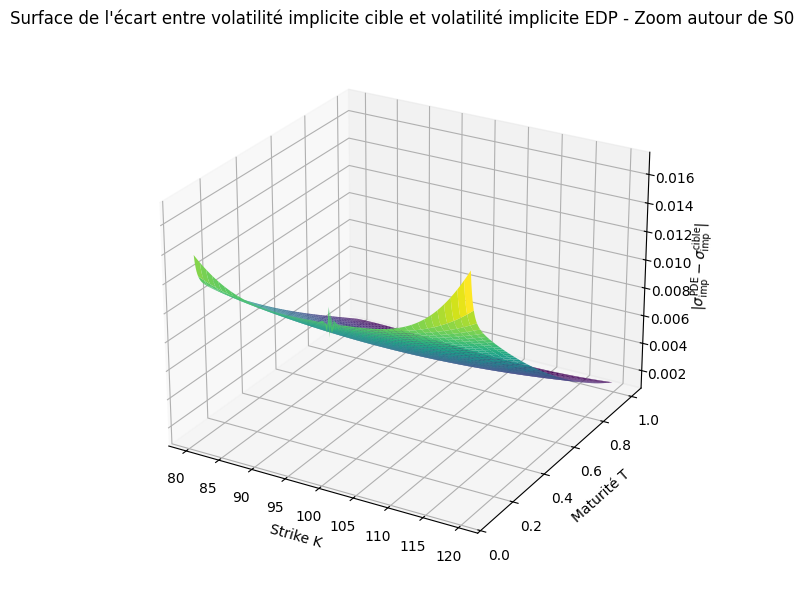

In [137]:
K_sub = K_CN[maskK]
T_sub = T_CN[maskT]

K_mesh_sub, T_mesh_sub = np.meshgrid(K_sub, T_sub)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    K_mesh_sub,
    T_mesh_sub,
    diff_sigma_sub,
    cmap="viridis",
    edgecolor="none",
    antialiased=True
)

ax.set_xlabel("Strike K")
ax.set_ylabel("Maturité T")
ax.set_zlabel(r"$|\sigma_{\mathrm{imp}}^{\mathrm{PDE}}-\sigma_{\mathrm{imp}}^{\mathrm{cible}}|$")
ax.view_init(elev=25, azim=-60)

plt.title("Surface de l'écart entre volatilité implicite cible et volatilité implicite EDP - Zoom autour de S0")
plt.tight_layout()
plt.show()

---

## 7.3 Comparaison avec le cas Black–Scholes à volatilité constante

On compare à présent la surface de prix obtenue avec la volatilité locale
au cas particulier d’une volatilité constante, correspondant au modèle
classique de Black–Scholes.

On considère l’écart :

$$
\Delta C(K,T)
=
\left|
C_{\mathrm{loc}}(K,T)
-
C_{\mathrm{BS}}(K,T)
\right|,
$$

où :

- $C_{\mathrm{loc}}$ désigne la surface issue du modèle de volatilité locale,
- $C_{\mathrm{BS}}$ la surface correspondant au modèle de Black–Scholes
  avec volatilité constante $\sigma_0$.

Afin de rendre cette section indépendante des précédentes,
nous réimplémentons explicitement le solveur Black–Scholes
dans le notebook.

### Résolution de l’EDP en volatilité constante

Dans le cas $\sigma_{\mathrm{loc}}(K,T)=\sigma_0$ constant,
l’EDP de Dupire devient :

$$
\partial_T C = \frac{1}{2}\sigma_0^2 K^2 \partial_{KK} C.
$$

Nous utilisons exactement le même schéma de Crank–Nicolson,
mais avec $\sigma_0$ constant. Le code ci-dessous a déjà été implémenté auparavant, on le remet afin d'être davantage autonome avec les sections précédentes.

In [138]:
def solve_BS():
    """
    Résolution de l'EDP de Dupire dans le cas sigma constant.
    Implémentation autonome (ne dépend pas des sections précédentes).
    """

    import numpy as np

    # Paramètres identiques à ceux du solveur local
    S0 = 100.0
    K_min, K_max = 0.4*S0, 1.6*S0
    T_max = 1.0
    M, N = 400, 250

    K = np.linspace(K_min, K_max, M+1)
    T = np.linspace(0.0, T_max, N+1)

    dK = K[1] - K[0]
    dT = T[1] - T[0]

    # Valeur constante choisie précédemment
    sigma0 = 0.248446

    def payoff_call(S0, K_grid):
        return np.maximum(S0 - K_grid, 0.0)

    C = np.zeros((N+1, M+1))
    C[0,:] = payoff_call(S0, K)

    C_left = max(S0 - K_min, 0.0)
    C_right = 0.0

    def apply_bc(C_slice):
        C_slice[0] = C_left
        C_slice[-1] = C_right

    apply_bc(C[0,:])

    def solve_tridiagonal(a, b, c, d):
        n = b.size
        cp = np.empty(n-1)
        dp = np.empty(n)
        cp[0] = c[0] / b[0]
        dp[0] = d[0] / b[0]
        for i in range(1, n-1):
            denom = b[i] - a[i-1]*cp[i-1]
            cp[i] = c[i] / denom
            dp[i] = (d[i] - a[i-1]*dp[i-1]) / denom
        dp[-1] = (d[-1] - a[-1]*dp[-2]) / (b[-1] - a[-1]*cp[-2])
        x = np.empty(n)
        x[-1] = dp[-1]
        for i in range(n-2, -1, -1):
            x[i] = dp[i] - cp[i]*x[i+1]
        return x

    K_inner = K[1:M]

    for n in range(N):
        alpha = (dT/(2*dK*dK)) * (sigma0**2) * (K_inner**2)

        a = -0.5 * alpha[1:]
        b = 1 + alpha
        c = -0.5 * alpha[:-1]

        Cn = C[n,:].copy()
        apply_bc(Cn)

        Cn_inner = Cn[1:M]
        Cn_im1 = Cn[0:M-1]
        Cn_ip1 = Cn[2:M+1]

        rhs = (1 - alpha) * Cn_inner + 0.5 * alpha * (Cn_im1 + Cn_ip1)
        rhs[0] += 0.5 * alpha[0] * C_left

        C_next = solve_tridiagonal(a, b, c, rhs)
        C[n+1,1:M] = C_next
        apply_bc(C[n+1,:])

    return C, K, T

Nous calculons maintenant les deux surfaces :

- $C_{\mathrm{loc}}$ via le modèle de volatilité locale,
- $C_{\mathrm{BS}}$ via le modèle Black–Scholes constant.

Puis nous évaluons l’écart absolu.

In [140]:
# Récupération des surfaces
C_loc, K_loc, T_loc = solve_CN()
C_bs,  K_bs,  T_bs  = solve_BS()

# Vérification des grilles
assert np.allclose(K_loc, K_bs)
assert np.allclose(T_loc, T_bs)

diff = np.abs(C_loc - C_bs)

print("==== Écart prix |C_loc - C_BS| ====")
print("max :", np.max(diff))
print("mean:", np.mean(diff))
print("L2  :", np.sqrt(np.mean(diff**2)))

==== Écart prix |C_loc - C_BS| ====
max : 1.5336763766638768
mean: 0.3968832965223195
L2  : 0.5707865824362143


### Heatmap — domaine complet

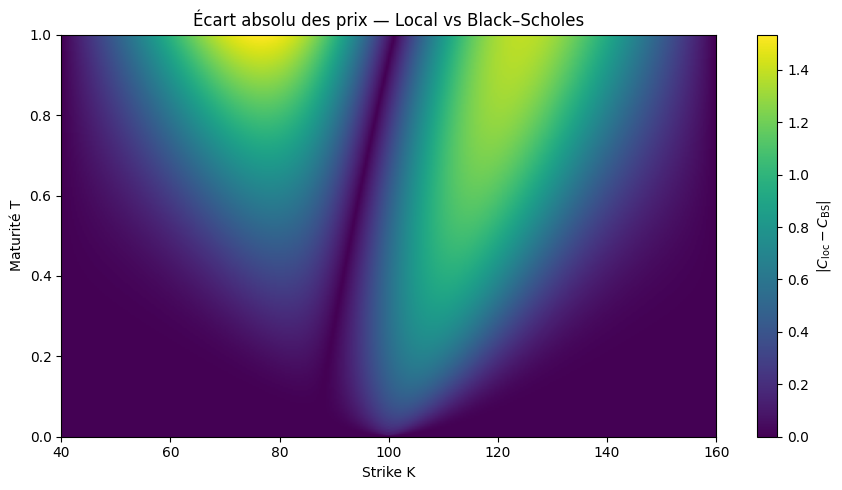

In [141]:
import matplotlib.pyplot as plt
K_mesh, T_mesh = np.meshgrid(K_loc, T_loc)

plt.figure(figsize=(9,5))
plt.imshow(diff, aspect="auto", origin="lower",
           extent=[K_loc.min(), K_loc.max(), T_loc.min(), T_loc.max()])
plt.colorbar(label=r"$|C_{\mathrm{loc}} - C_{\mathrm{BS}}|$")
plt.xlabel("Strike K")
plt.ylabel("Maturité T")
plt.title("Écart absolu des prix — Local vs Black–Scholes")
plt.tight_layout()
plt.show()

### Surface 3D — domaine complet

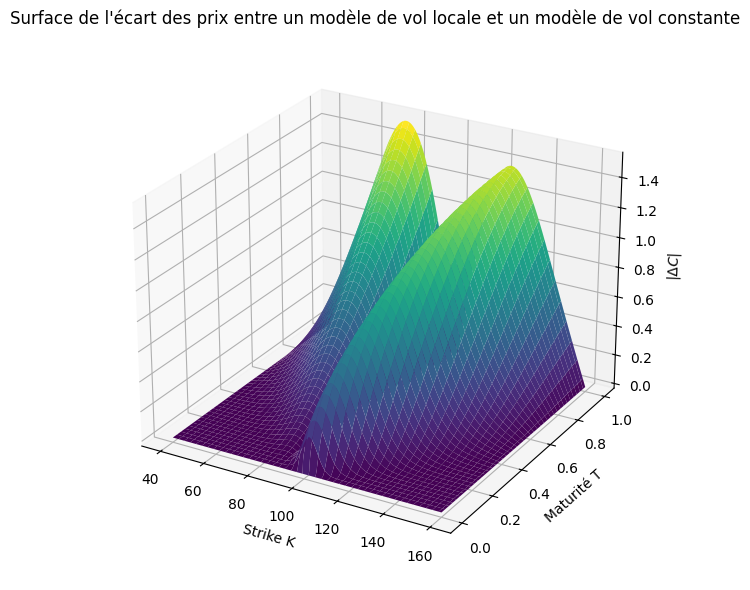

In [142]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(K_mesh, T_mesh, diff,
                cmap="viridis", edgecolor="none")
ax.set_xlabel("Strike K")
ax.set_ylabel("Maturité T")
ax.set_zlabel(r"$|\Delta C|$")
ax.view_init(elev=25, azim=-60)
plt.title("Surface de l'écart des prix entre un modèle de vol locale et un modèle de vol constante")
plt.tight_layout()
plt.show()

---

# Conclusion

Dans ce notebook, nous avons étudié le modèle de volatilité locale de Dupire
du point de vue analytique et numérique.

À partir d’une surface de volatilité implicite cible, nous avons construit
une volatilité locale $\sigma_{\mathrm{loc}}(K,T)$ via la formule de Dupire,
puis résolu numériquement l’équation aux dérivées partielles correspondante
à l’aide de schémas aux différences finies (Euler implicite et Crank–Nicolson).
La structure tridiagonale des systèmes linéaires obtenus a permis une
résolution efficace grâce à l’algorithme de Thomas.

Les comparaisons numériques montrent :

- une forte cohérence entre les schémas implicite et Crank–Nicolson,
  les écarts étant principalement localisés aux petites maturités,
  en lien avec la singularité de la condition initiale ;
- une bonne capacité du modèle de Dupire à reproduire la surface implicite
  cible dans la zone centrale du domaine de calibration ;
- un écart significatif avec le modèle de Black–Scholes à volatilité constante,
  illustrant l’importance de la dépendance en $(K,T)$ de la volatilité locale.

D’un point de vue mathématique, les résultats mettent en évidence
le rôle régularisant de l’opérateur parabolique : à mesure que la maturité
augmente, la diffusion en strike lisse la solution et atténue les effets
de la singularité initiale ainsi que les erreurs de discrétisation.

Ainsi, l’ensemble des expériences numériques valide la chaîne de construction :

$$
\sigma_{\mathrm{imp}}^{\mathrm{cible}}
\;\longrightarrow\;
\sigma_{\mathrm{loc}}
\;\longrightarrow\;
C_{\mathrm{PDE}}
\;\longrightarrow\;
\sigma_{\mathrm{imp}}^{\mathrm{reconstruite}},
$$

confirmant la cohérence globale du modèle et de son implémentation.

Ce travail illustre la manière dont une équation parabolique dégénérée,
issue de considérations probabilistes, peut être exploitée numériquement
pour relier surfaces implicites observées et dynamique locale du sous-jacent,
dans un cadre rigoureux et cohérent.